# Cleaning and Standardizing the Data

Cleaning the Learners Dataset

In [157]:
import pandas as pd
df_learners = pd.read_excel(io='educate_linked_challenge_dirty_assessment.xlsx', sheet_name='learners')
df_learners.head()

,learner_id,gender,grade,registration_date
0,LND1000,F,12,2026-06-13
1,LND1001,F,10,2026-01-29
2,LND1002,F,10,2026-01-07
3,LND1003,F,12,2026-03-12
4,LND1004,F,Grade 11,2026-03-04


The first step is to identify records with inconsistent formatting and missing values.

We can standardize the formatting by converting values to uppercase.

For missing values, we can impute them with the index number because each learner ID follows the same pattern.

In [158]:
df_learners[~df_learners['learner_id'].str.contains("LND")]

,learner_id,gender,grade,registration_date
27,lnd1025,F,12,2026-02-26
30,lnd1028,Female,12,2026-03-13
58,lnd1057,Female,Grade 11,2026-04-03
88,lnd1086,M,10,2026-03-04
118,lnd1115,Male,12,2026-03-05
146,lnd1144,Non-binary,Grade 11,2026-03-06
153,NaN,NaN,12,not_a_date
154,NaN,NaN,10,2026-01-21


In [159]:
rows = df_learners['learner_id'].str.contains("lnd")
df_learners.loc[rows, 'learner_id'] = df_learners.loc[rows, 'learner_id'].str.upper()

In [160]:
df_learners[~df_learners['learner_id'].str.contains("LND")]

,learner_id,gender,grade,registration_date
153,NaN,NaN,12,not_a_date
154,NaN,NaN,10,2026-01-21


Now to drop the Missing Values because we cannot resonably guess a students ID

In [161]:
df_learners.dropna(subset=['learner_id'], inplace=True)
df_learners[~df_learners['learner_id'].str.contains("LND")]

,learner_id,gender,grade,registration_date


Now we can try and find out where `Sci` belongs

In [162]:
df_learners[~df_learners['learner_id'].str.contains("LND")]

,learner_id,gender,grade,registration_date


In [163]:
df_learners.drop(df_learners[df_learners['learner_id'] == "LND9999"].index, inplace=True)
df_learners.tail()

,learner_id,gender,grade,registration_date
147,LND1145,Non-binary,12,2026-05-22
148,LND1146,Prefer not say,12,2026-01-03
149,LND1147,Unknown,10,2026-06-24
150,LND1148,Unknown,10,2026-04-19
151,LND1149,NaN,G11,2026-03-30


For the gender field, it is best to first review the unique values and then create a mapping to standardize the categories.

In [164]:
df_learners['gender'].unique()

<StringArray>
[             'F',              'f',         'Female',         'female',
              'M',              'm',           'Male',           'MALE',
     'Non-binary', 'Prefer not say',        'Unknown',              nan]
Length: 12, dtype: str

For simplicity, we can standardize the gender values using the following mapping:

In [165]:
import numpy as np
gender_mask = {'M':'Male',
                'MALE':'Male',
                'm':'Male',

                'F':'Female',
                'female':'Female',
                'f':'Female',

                'Unknown':np.nan,

                'Prefer not say': 'Prefer not to say'}

for to_replace, replace in gender_mask.items():
    df_learners['gender'] = df_learners['gender'].replace(to_replace=to_replace, value=replace)

In [166]:
#Evaluating the distribution of genders
data = df_learners['gender'].value_counts().reset_index()
data

,gender,count
0,Male,65
1,Female,63
2,Non-binary,20
3,Prefer not to say,1


In [167]:
import plotly.express as px

fig = px.bar(data_frame = data, x = 'count', y = 'gender',orientation='h')
fig.show()

In [168]:
df_learners.fillna({'gender': 'Prefer not to say'}, inplace=True)
#Finding out how many missing values there are
df_learners['gender'].isna().value_counts()

gender
False    152
Name: count, dtype: int64

### Data Cleaning: Standardize the `grade` Column

Convert all entries in the `grade` column to a consistent integer data type to ensure data quality and consistency.

In [169]:
df_learners['grade'].unique()

array([12, 10, '12', 'Grade 11', 11, 'grade12', 9, 'G11', 'Gr 10',
       'Grade Ten'], dtype=object)

In [170]:
#Converting string grades to integers

grade_mask = {'Grade 11': 11,
            'grade12': 12,
            'G11': 11,
            'Gr 10': 10,
            'Grade Ten': 10,
            '12':12,
            9: 10}

for to_replace, replace in grade_mask.items():
    df_learners['grade'] = df_learners['grade'].replace(to_replace=to_replace, value=replace)

In [171]:
#Converting all rows to integer data type
df_learners['grade'].astype('int').dtype

dtype('int64')

In [172]:
#Checking for missing values
df_learners['grade'].isna().value_counts()

grade
False    152
Name: count, dtype: int64

### Data Cleaning: Standardize the `registration_date` Column

Convert all entries in the `registration_date` column to a consistent `datetime64` format to ensure temporal consistency across the dataset.

In [173]:
valid_str_date = df_learners['registration_date'].astype('str').str.startswith('2026-')
valid_str_date

0      True
1      True
2      True
3      True
4      True
       ... 
147    True
148    True
149    True
150    True
151    True
Name: registration_date, Length: 152, dtype: bool

In [174]:
df_learners[~valid_str_date]['registration_date'].unique()

<StringArray>
['15/02/2026', 'not_a_date', 'May 21 2026', '03/07/26', nan, '18-05-2026']
Length: 6, dtype: str

When we review the unique values in the column, we find six irregular entries. The first step is to replace `not_a_date` with `NaN`, and then convert the remaining invalid values to the correct `datetime64` format (`YYYY-MM-DD`).

In [175]:
df_learners['registration_date'] = df_learners['registration_date'].replace(to_replace='not_a_date', value=np.nan)

df_learners[~valid_str_date]['registration_date'].unique()

<StringArray>
['15/02/2026', nan, 'May 21 2026', '03/07/26', '18-05-2026']
Length: 5, dtype: str

In [176]:
mask = {'15/02/2026': '2026-02-15',
        'May 21 2026': '2026-05-21',
        '03/07/26': '2026-07-03',
        '18-05-2026': '2026-05-18'}

for to_replace, replace in mask.items():
        df_learners['registration_date'] = df_learners['registration_date'].replace(to_replace=to_replace, value=replace)

In [177]:
#Checking if we resolved these errors
df_learners[~df_learners['registration_date'].astype('str').str.startswith('2026')]['registration_date']

20     NaN
63     NaN
141    NaN
Name: registration_date, dtype: str

At this point, only a few invalid values remain. Since they represent a small proportion of the dataset, we can drop these rows after the remaining datasets have been cleaned and we have assessed their impact on overall data quality.

# Cleaning the Engagement Dataset

In [178]:
df_eng = pd.read_excel(io='educate_linked_challenge_dirty_assessment.xlsx', sheet_name='engagement')
df_eng.tail()

,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes
194,LND1148,Sci,86%,11.0,"142,3"
195,LND1149,Sci,88%,18.0,"15,7"
196,LND1149,Sci,98.4%,18.0,"262,7"
197,LND9999,NaN,NaN,40.0,"332,4"
198,TEMP-004,NaN,NaN,NaN,NaN


### Cleaning the `learner_id` Column

In [179]:
#Dropping duplicate rows
df_eng = df_eng.drop_duplicates().reset_index(drop=True)
# Drop the row where learner_id is TEMP-004
df_eng = df_eng[~df_eng['learner_id'].isin(['TEMP-004','LND9999'])].reset_index(drop=True)

#Drop rows where learner_id is null
df_eng = df_eng.dropna(subset=['learner_id']).reset_index(drop=True)

In [180]:
df_eng.tail()

,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes
191,LND1147,Sci,67.5%,40.0,919.7
192,LND1147,Sci,72%,40.0,"104,6"
193,LND1148,Sci,86%,11.0,"142,3"
194,LND1149,Sci,88%,18.0,"15,7"
195,LND1149,Sci,98.4%,18.0,"262,7"


In [181]:
#Find which rows have errors (not starting with 'LND')
mask = df_eng['learner_id'].str.startswith('LND')

df_eng[~mask]['learner_id']

47     lnd1029
94     lnd1067
139    lnd1107
187    lnd1143
Name: learner_id, dtype: str

We can standardize them by converting them to uppercase.

In [182]:
df_eng['learner_id'] = df_eng['learner_id'].str.upper()

df_eng[~df_eng['learner_id'].str.startswith('LND')]

,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes


### Cleaning the `subject` Column

First, let us identify the unique values and assess how widespread the errors are.

In [183]:
df_eng['subject'].unique()

<StringArray>
[       'Accounting',        'accounting',     'Life Sciences',
     'life sciences',                'LS',              'Math',
       'Mathematics',             'Maths',             'maths',
 'Physical Sciences',               'Sci']
Length: 11, dtype: str

Expected Standard Format:

- Mathematics
- Accounting
- Life Science

In [184]:
mask = {('accounting',): 'Accounting',
        ('maths', 'Math', 'Maths', '  Mathematics '): 'Mathematics',
        ('LS', 'life sciences', 'Life Sciences'): 'Life Science',
        ('Physical Sciences',): 'Physical Science'}


for to_replace, replace in mask.items():
        df_eng['subject'] = df_eng['subject'].replace(to_replace=list(to_replace), value=replace)

The value `Sci` is ambiguous because it could represent either `Life Science` or `Physical Science`.

Let us determine how often `Sci` appears in the dataset.

In [185]:
df_eng['subject'].value_counts()['Sci']

np.int64(34)

Since there are 34 rows with this value, we cannot simply drop them.

Instead, we need to determine how `Life Science` and `Physical Science` relate to the other fields (excluding `learner_id`), and then impute `Sci` based on those patterns.

Before doing this, we first need to clean the remaining fields.

#### Cleaning the `tutoring_attendance_pct` Column

In [186]:
#Toutoring atterndance percent column
#Remove "%"
df_eng['tutoring_attendance_pct'] = df_eng['tutoring_attendance_pct'].astype('str').str.removesuffix("%")

df_eng[df_eng['tutoring_attendance_pct'].str.contains("%")]['tutoring_attendance_pct']

Series([], Name: tutoring_attendance_pct, dtype: str)

In [187]:
#Remove negative values
df_eng['tutoring_attendance_pct'] = df_eng['tutoring_attendance_pct'].astype('float').abs()

print("Minimum value: ",df_eng['tutoring_attendance_pct'].min())

print("Maximim value: ", df_eng['tutoring_attendance_pct'].max())

Minimum value:  8.0
Maximim value:  999.0


In [188]:
#Replace values greater than 100 with 100
df_eng['tutoring_attendance_pct'] = np.where(df_eng['tutoring_attendance_pct'] > 100.0, 100.0, df_eng['tutoring_attendance_pct'])

print("Minimum value: ",df_eng['tutoring_attendance_pct'].min())

print("Maximim value: ", df_eng['tutoring_attendance_pct'].max())

Minimum value:  8.0
Maximim value:  100.0


In [189]:
df_eng['tutoring_attendance_pct'].describe()

count    196.000000
mean      75.698980
std       15.354244
min        8.000000
25%       63.375000
50%       74.850000
75%       88.750000
max      100.000000
Name: tutoring_attendance_pct, dtype: float64

#### Cleaning `videos_watched` column
* Removing negative values 
* Changing datatype from object to integer

In [190]:
#Find missing values
df_eng[df_eng['videos_watched'].isnull()]


,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes


In [191]:
#Remove negative values
df_eng['videos_watched'] = df_eng['videos_watched'].astype('float').abs()

#### Cleaning the `watch_time_minutes` Column

- Remove negative values
- Replace commas with periods

In [192]:
#Removing ',' with '.'
df_eng['watch_time_minutes'] = df_eng['watch_time_minutes'].astype('str').str.replace(',','.')
df_eng[~df_eng['watch_time_minutes'].str.contains('.')]

,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes


In [193]:
#Remove negative values
df_eng['watch_time_minutes'] = df_eng['watch_time_minutes'].astype('float').abs()
print(df_eng['watch_time_minutes'].describe())

print('\nNull values: ',df_eng['watch_time_minutes'].isnull().value_counts())

count    196.000000
mean     324.652041
std      240.955454
min        0.000000
25%      118.000000
50%      306.200000
75%      509.825000
max      919.700000
Name: watch_time_minutes, dtype: float64

Null values:  watch_time_minutes
False    196
Name: count, dtype: int64


Now we can determine where `Sci` belongs.

In [194]:
df_eng['subject'].unique()

<StringArray>
['Accounting', 'Life Science', 'Mathematics', 'Physical Science', 'Sci']
Length: 5, dtype: str

In [195]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

features = [
    'tutoring_attendance_pct',
    'videos_watched',
    'watch_time_minutes'
]

# Use only rows with known subject labels
known_rows = df_eng['subject'].isin(
    ['Life Science', 'Physical Science']
)

# Feature data
X = df_eng.loc[known_rows, features]

# Target data
y_text = df_eng.loc[known_rows, 'subject']

# Encode the target subjects
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

# Create the pipeline
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

# Create stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate the complete pipeline
cv_results = cross_validate(
    model_pipeline,
    X,
    y,
    cv=cv,
    scoring=[
        'accuracy',
        'precision_macro',
        'recall_macro',
        'f1_macro'
    ]
)

print('Accuracy:', cv_results['test_accuracy'])
print('Mean accuracy:', cv_results['test_accuracy'].mean())

print('Mean precision:',
    cv_results['test_precision_macro'].mean())

print('Mean recall:',
    cv_results['test_recall_macro'].mean())

print('Mean F1-score:',
    cv_results['test_f1_macro'].mean())

Accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0
Mean precision: 1.0
Mean recall: 1.0
Mean F1-score: 1.0


In [196]:
model_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['tutoring_attendance_pct','videos_watched','watch_time_minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data t

Now we use the model to automatically classify what `Sci` is for each row based on its features.

In [197]:
sci_rows = df_eng['subject'].eq('Sci')

predicted_labels = model_pipeline.predict(
    df_eng.loc[sci_rows, features])

predicted_subjects = label_encoder.inverse_transform(
    predicted_labels)

df_eng.loc[sci_rows, 'subject'] = predicted_subjects

df_eng.tail(10)

,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes
186,LND1143,Physical Science,100.0,39.0,867.0
187,LND1143,Physical Science,100.0,40.0,873.4
188,LND1144,Physical Science,100.0,40.0,880.2
189,LND1146,Physical Science,100.0,40.0,891.9
190,LND1146,Physical Science,100.0,40.0,904.9
191,LND1147,Physical Science,67.5,40.0,919.7
192,LND1147,Life Science,72.0,40.0,104.6
193,LND1148,Life Science,86.0,11.0,142.3
194,LND1149,Life Science,88.0,18.0,15.7
195,LND1149,Life Science,98.4,18.0,262.7


### Cleaning the `assessments` Dataset

- For `learner_id` column: Change `lnd` to `LND`

- Drop LND9999

- `subject` column: Exoected standard `[Accounting, Life Science, 'Mathematics', Physical Science]

- `baseline_mark` column: 

    * Fix negative values using absolute function. 
    * Remove `%`. 
    * Replace `MISSING` with `NaN`
    * Replace  values exceeding 100 with 100

In [198]:
df_assessment = pd.read_excel(io='educate_linked_challenge_dirty_assessment.xlsx', sheet_name='assessments')
df_assessment.tail()

,learner_id,subject,baseline_mark,latest_mark
193,LND1147,Sci,67%,1050
194,LND1148,Sci,MISSING,1050
195,LND1149,Sci,MISSING,44
196,LND1149,Sci,MISSING,64
197,LND9999,Sci,MISSING,93


In [199]:
df_assessment.drop_duplicates(inplace=True)

#### Cleaning the `learner_id` Column

In [200]:
df_assessment= df_assessment[df_assessment['learner_id'] != 'LND9999']
df_assessment.tail()

,learner_id,subject,baseline_mark,latest_mark
192,LND1147,Sci,62%,1050
193,LND1147,Sci,67%,1050
194,LND1148,Sci,MISSING,1050
195,LND1149,Sci,MISSING,44
196,LND1149,Sci,MISSING,64


In [201]:
df_assessment['learner_id'] = df_assessment['learner_id'].str.upper()
df_assessment[~df_assessment['learner_id'].str.startswith('LND')]

,learner_id,subject,baseline_mark,latest_mark


#### Cleaning the `subject` Column

In [202]:
df_assessment['subject'].unique()

<StringArray>
[              'ACC',        'Accounting',      'Life Science',
     'Life Sciences',     'life sciences',              'Math',
       'Mathematics',       'MATHEMATICS',             'Maths',
             'maths',          'phys sci',  'Physical Science',
 'Physical Sciences',               'Sci']
Length: 14, dtype: str

In [203]:
mask = {('ACC',): 'Accounting',
        ('Life Sciences','life sciences'): 'Life Science',
        ('Math','Maths','maths','MATHEMATICS'):'Mathematics',
        ('Physical Sciences','phys sci'):'Physical Science'}

for to_replace, replace in mask.items():
        df_assessment['subject'] = df_assessment['subject'].replace(to_replace=list(to_replace), value=replace)

df_assessment['subject'].unique()

<StringArray>
['Accounting', 'Life Science', 'Mathematics', 'Physical Science', 'Sci']
Length: 5, dtype: str

In [204]:
df_eng

,learner_id,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes
0,LND1000,Accounting,8.0,3.0,45.0
1,LND1000,Accounting,50.3,3.0,45.0
2,LND1001,Accounting,50.4,0.0,15.5
3,LND1001,Accounting,51.0,0.0,15.5
4,LND1002,Accounting,51.0,0.0,15.5
...,...,...,...,...,...
191,LND1147,Physical Science,67.5,40.0,919.7
192,LND1147,Life Science,72.0,40.0,104.6
193,LND1148,Life Science,86.0,11.0,142.3
194,LND1149,Life Science,88.0,18.0,15.7


In [205]:
# Using learner_id to align the science subjects across the two datasets
science_subjects = df_eng.loc[sci_rows, ['learner_id', 'subject']].drop_duplicates('learner_id').set_index('learner_id')['subject']
science_subjects

learner_id
LND1125    Physical Science
LND1126    Physical Science
LND1127    Physical Science
LND1130    Physical Science
LND1131    Physical Science
LND1132    Physical Science
LND1134    Physical Science
LND1135    Physical Science
LND1136    Physical Science
LND1137    Physical Science
LND1138    Physical Science
LND1139    Physical Science
LND1140    Physical Science
LND1141    Physical Science
LND1142    Physical Science
LND1143    Physical Science
LND1144    Physical Science
LND1146    Physical Science
LND1147    Physical Science
LND1148        Life Science
LND1149        Life Science
Name: subject, dtype: str

In [206]:
assessment_sci_rows = df_assessment['subject'].eq('Sci')
assessment_sci_rows

0      False
1      False
2      False
3      False
4      False
       ...  
192     True
193     True
194     True
195     True
196     True
Name: subject, Length: 168, dtype: bool

In [207]:
assessment_subjects = df_assessment.loc[assessment_sci_rows, 'learner_id'].map(science_subjects).rename('subject')
assessment_subjects

163    Physical Science
164    Physical Science
166    Physical Science
168    Physical Science
170    Physical Science
171    Physical Science
173    Physical Science
174    Physical Science
175    Physical Science
176    Physical Science
178    Physical Science
179    Physical Science
181    Physical Science
183    Physical Science
184    Physical Science
185    Physical Science
186    Physical Science
187    Physical Science
188    Physical Science
189    Physical Science
190    Physical Science
191    Physical Science
192    Physical Science
193    Physical Science
194        Life Science
195        Life Science
196        Life Science
Name: subject, dtype: str

In [208]:
df_assessment.loc[assessment_sci_rows, 'subject'] = assessment_subjects
df_assessment['subject'].unique()

<StringArray>
['Accounting', 'Life Science', 'Mathematics', 'Physical Science']
Length: 4, dtype: str

#### Cleaning the `baseline_mark` Column

In [209]:
for col in ['latest_mark', 'baseline_mark']:

    df_assessment[col] = df_assessment[col].astype('str').str.replace('%','')

    df_assessment[col] = df_assessment[col].replace('MISSING', np.nan).astype('Int64').abs()

    df_assessment.loc[df_assessment[col] > 100, col] = 100

    df_assessment.fillna({col: df_assessment[col].median()}, inplace=True)

    print(df_assessment[col].describe(),'\n')

count        168.0
mean      70.35119
std      18.169244
min           31.0
25%          56.75
50%           72.0
75%          83.25
max          100.0
Name: latest_mark, dtype: Float64 

count        168.0
mean     53.261905
std      14.191267
min            5.0
25%           42.0
50%           55.0
75%           64.0
max          100.0
Name: baseline_mark, dtype: Float64 



### Cleaning the `support_capacity` Dataset

- It seems like each subject have duplicate rows

- Considering how simple this, I can just manually drop rows that having missing values while ensuring I keep rows that are complete and have minimal errors

- Rows to keep: 0, 1, 2, 3

In [210]:
df_support = pd.read_excel(io='educate_linked_challenge_dirty_assessment.xlsx', sheet_name='support_capacity')

df_support

,subject,active_tutors,weekly_tutor_hours,waiting_list,estimated_cost_per_extra_hour
0,Maths,4,26,31.0,180
1,Physical Sciences,3,18,28.0,210
2,Life Sciences,3,22,14.0,165
3,Accounting,2,15,19.0,175
4,maths,4,26 hrs,31.0,R180
5,Physical Science,3,18,NaN,210
6,Life sciences,3,-2,14.0,165
7,ACC,2,15,19.0,175.00


In [211]:
df_support = df_support.drop(index=[4,5,6,7]).reset_index(drop=True)
df_support

,subject,active_tutors,weekly_tutor_hours,waiting_list,estimated_cost_per_extra_hour
0,Maths,4,26,31.0,180
1,Physical Sciences,3,18,28.0,210
2,Life Sciences,3,22,14.0,165
3,Accounting,2,15,19.0,175


In [212]:
mask = {('Maths',): 'Mathematics',
        ('Physical Sciences',): 'Physical Science',
        ('Life Sciences',): 'Life Science'}

for to_replace, replace in mask.items():
        df_support['subject'] = df_support['subject'].replace(to_replace=list(to_replace), value=replace)

df_support[['active_tutors','weekly_tutor_hours','waiting_list','estimated_cost_per_extra_hour']] = df_support[['active_tutors','weekly_tutor_hours','waiting_list','estimated_cost_per_extra_hour']].astype('Int64')

df_support.dtypes

subject                            str
active_tutors                    Int64
weekly_tutor_hours               Int64
waiting_list                     Int64
estimated_cost_per_extra_hour    Int64
dtype: object

In [213]:
df_support

,subject,active_tutors,weekly_tutor_hours,waiting_list,estimated_cost_per_extra_hour
0,Mathematics,4,26,31,180
1,Physical Science,3,18,28,210
2,Life Science,3,22,14,165
3,Accounting,2,15,19,175


### Cleaning the `Enquiries` Dataset

- Drop `ENQ9999`. The value in field `converted_to_registration` contains `maybe` instead of `Yes` or `No`.

- `enquiry_date` column: replace `14/06/2026` to `2026-06-14`

- `grade` column: Remove `Grade` prefix. Replace grades greater than 12 with 12

- `subject` column: Standerdization (Accounting, Life Science, 'Mathematics', Physical Science)

- `converted_to_registration` column: Standerdization (Yes, No). Impute missing values with the most occuring value based on overall observation of `Grade` and `Subject` from the entire table. For example, if the most occuring value for `converted_to_registration` is `Yes` when the grade is 12 and subject is Mathematics, then I'll impute the missing value with `Yes` while considering grade and subject.

In [214]:
df_enq = pd.read_excel(io='educate_linked_challenge_dirty_assessment.xlsx', sheet_name='enquiries')

In [215]:
df_enq.drop(df_enq[df_enq['enquiry_id'] == 'ENQ9999'].index, axis=0, inplace=True)
df_enq.drop_duplicates(inplace=True)
df_enq.tail()

,enquiry_id,enquiry_date,grade,subject,converted_to_registration
116,ENQ0116,2026-07-28,12,Physical Sciences,N
117,ENQ0117,2026-07-29,12,Physical Sciences,Y
118,ENQ0118,2026-07-29,12,Physical Sciences,N
119,ENQ0119,2026-07-29,12,Physical Sciences,0
120,ENQ0120,2026-07-30,13,Physical Sciences,Y


In [216]:
df_enq['enquiry_date'] = df_enq['enquiry_date'].replace('14/06/2026', '2026-06-14')

df_enq['grade'] = df_enq['grade'].astype('string').str.replace('Grade ','').astype('Int64')

df_enq.loc[df_enq['grade'] > 12, 'grade'] = 12

In [217]:
df_enq['grade'].describe()

count        120.0
mean     10.983333
std       0.766782
min           10.0
25%           10.0
50%           11.0
75%           12.0
max           12.0
Name: grade, dtype: Float64

In [218]:
df_enq['subject'].unique()

<StringArray>
[       'Accounting',     'Life Sciences',       'Mathematics',
             'Maths',             'maths',          'phys sci',
 'Physical Sciences']
Length: 7, dtype: str

In [219]:
mask = {('Maths','maths'): 'Mathematics',
        ('phys sci','Physical Sciences'): 'Physical Science',
        ('Life Sciences',): 'Life Science'}

for to_replace, replace in mask.items():
        df_enq['subject'] = df_enq['subject'].replace(to_replace=list(to_replace), value=replace)

df_enq['subject'].unique()

<StringArray>
['Accounting', 'Life Science', 'Mathematics', 'Physical Science']
Length: 4, dtype: str

In [220]:
df_enq['converted_to_registration'].unique()

array(['Y', 1, 'N', 'No', 0, 'Yes', nan], dtype=object)

In [221]:
mask = {('Y', 1): 'Yes',
        ('N', 0): 'No'}

for to_replace, replace in mask.items():
    df_enq['converted_to_registration'] = df_enq['converted_to_registration'].replace(to_replace=list(to_replace), value=replace)

df_enq['converted_to_registration'].unique()

array(['Yes', 'No', nan], dtype=object)

In [222]:
d = df_enq[['grade','subject','converted_to_registration']].groupby(['grade','subject'])['converted_to_registration'].value_counts().unstack().reset_index()
d

converted_to_registration,grade,subject,No,Yes
0,10,Accounting,8,4
1,10,Life Science,7,7
2,10,Mathematics,6,4
3,11,Mathematics,23,19
4,11,Physical Science,3,4
5,12,Physical Science,17,17


In [223]:
d['mode'] = d[['Yes', 'No']].idxmax(axis=1)
d

converted_to_registration,grade,subject,No,Yes,mode
0,10,Accounting,8,4,No
1,10,Life Science,7,7,Yes
2,10,Mathematics,6,4,No
3,11,Mathematics,23,19,No
4,11,Physical Science,3,4,Yes
5,12,Physical Science,17,17,Yes


In [224]:
# Create a mapping from grade-subject to the most common value
mode_mapping = dict(zip(zip(d['grade'], d['subject']), d['mode']))
mode_mapping

{(np.int64(10), 'Accounting'): 'No',
 (np.int64(10), 'Life Science'): 'Yes',
 (np.int64(10), 'Mathematics'): 'No',
 (np.int64(11), 'Mathematics'): 'No',
 (np.int64(11), 'Physical Science'): 'Yes',
 (np.int64(12), 'Physical Science'): 'Yes'}

In [225]:
# Fill missing values
for (grade, subject), mode_val in mode_mapping.items():
    mask = (df_enq['grade'] == grade) & (df_enq['subject'] == subject) & (df_enq['converted_to_registration'].isna())
    df_enq.loc[mask, 'converted_to_registration'] = mode_val

df_enq['converted_to_registration'].isna().value_counts()

converted_to_registration
False    120
Name: count, dtype: int64

In [226]:
"""# Export each cleaned DataFrame to a separate Excel worksheet
import os

wd = os.getcwd()

output_path = os.path.join(wd, 'cleaned_data.xlsx')

dataframes = {
    'Learners': df_learners,
    'Engagement': df_eng,
    'Assessments': df_assessment,
    'Support Capacity': df_support,
    'Enquiries': df_enq
}

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for sheet_name, dataframe in dataframes.items():
        dataframe.to_excel(writer, sheet_name=sheet_name, index=False)

print(f'File saved to: {output_path}')"""

File saved to: /home/katlego/Work/BIH Assignement/cleaned_data.xlsx


# Joining the datasets

### Correct keys to use for join

- For `Learners`, `Engagement`, and `Assessments` datasets, the correct keys to use when joining these tables are "learner_id"

- `learner_id` have a lot of unique values for it to qualify as a primary and foreign keys for these tables.

- However, to join these three tables along with `Support Capacity` and `Enquiries`, the correct keys to use would be `subjects`


### Best join strategy

- For all datasets, the best join strategy would be a `left join`. This is because the `Learners` datasets, does not have a lot of duplicates rows on the `learner_id` column and makes it a perfect `template` for the other tables to follow when joining. This ensures that there is not a lot of data duplication on the entire dataset and prevent misguded analysis.

- Now as I am joining these tables, there will obviously be multiplied records from `learner_id`. Mainly caused by the `Engagement` and `Assessemts` tables.

- Before I came to this step, I know I could have merged rows in the `Engagement` and `Assessements` tables that have the same `learner_id` and `subject` then merging the rows fields using the average. For example, if in the `Assessments` table, if `LND1234` is present in two rows with the same subjects (Accounting) but have different `baseline_marks` and `latest_marks` values, I would simply use the `mean` (average) function to combaine those rows into one.

In [227]:
#Learners and Engagement
df_len_eng = pd.merge(df_learners, df_eng, how='left', on='learner_id')
df_len_eng

,learner_id,gender,grade,registration_date,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes
0,LND1000,Female,12,2026-06-13,Accounting,8.0,3.0,45.0
1,LND1000,Female,12,2026-06-13,Accounting,50.3,3.0,45.0
2,LND1001,Female,10,2026-01-29,Accounting,50.4,0.0,15.5
3,LND1001,Female,10,2026-01-29,Accounting,51.0,0.0,15.5
4,LND1002,Female,10,2026-01-07,Accounting,51.0,0.0,15.5
...,...,...,...,...,...,...,...,...
219,LND1147,Prefer not to say,10,2026-06-24,Physical Science,67.5,40.0,919.7
220,LND1147,Prefer not to say,10,2026-06-24,Life Science,72.0,40.0,104.6
221,LND1148,Prefer not to say,10,2026-04-19,Life Science,86.0,11.0,142.3
222,LND1149,Prefer not to say,11,2026-03-30,Life Science,88.0,18.0,15.7


- From the table above, we see that multiple `learner_id's` have multiplied

- We also see that some learners have missing values in some fields (e.g. `LND1004`). To solve that, we can just simply drop the rows because it does not have a lot of information that I can work with to at least impute those missing values. For example, I cannot impute the missing value in the `Subject` column if I don't have data from the `tutoring_attendance_pct`, `videos_watched`, and `watch_time_minutes` columns.

In [228]:
df_len_eng.isnull()[['subject','tutoring_attendance_pct','videos_watched','watch_time_minutes']].sum()

subject                    24
tutoring_attendance_pct    24
videos_watched             24
watch_time_minutes         24
dtype: int64

In [229]:
condition = df_len_eng[['subject','tutoring_attendance_pct','videos_watched','watch_time_minutes']].notnull().any(axis=1)
df_len_eng =df_len_eng.loc[condition]
df_len_eng.isnull()[['subject','tutoring_attendance_pct','videos_watched','watch_time_minutes']].sum()

subject                    0
tutoring_attendance_pct    0
videos_watched             0
watch_time_minutes         0
dtype: int64

In [230]:
#(Learners and Engagement) and Assessments
df_len_eng_ass = pd.merge(df_len_eng, df_assessment.drop(['subject'], axis=1), how='left', on=['learner_id'])
df_len_eng_ass

,learner_id,gender,grade,registration_date,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes,baseline_mark,latest_mark
0,LND1000,Female,12,2026-06-13,Accounting,8.0,3.0,45.0,5,31
1,LND1000,Female,12,2026-06-13,Accounting,8.0,3.0,45.0,30,32
2,LND1000,Female,12,2026-06-13,Accounting,50.3,3.0,45.0,5,31
3,LND1000,Female,12,2026-06-13,Accounting,50.3,3.0,45.0,30,32
4,LND1001,Female,10,2026-01-29,Accounting,50.4,0.0,15.5,30,34
...,...,...,...,...,...,...,...,...,...,...
280,LND1148,Prefer not to say,10,2026-04-19,Life Science,86.0,11.0,142.3,55,100
281,LND1149,Prefer not to say,11,2026-03-30,Life Science,88.0,18.0,15.7,55,44
282,LND1149,Prefer not to say,11,2026-03-30,Life Science,88.0,18.0,15.7,55,64
283,LND1149,Prefer not to say,11,2026-03-30,Life Science,98.4,18.0,262.7,55,44


In [231]:
#Now to handle the multiplied `learner_id` values
df_len_eng_ass = df_len_eng_ass.groupby(['learner_id','gender','grade','registration_date','subject']).mean().round(0).reset_index()
df_len_eng_ass

,learner_id,gender,grade,registration_date,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes,baseline_mark,latest_mark
0,LND1000,Female,12,2026-06-13,Accounting,29.0,3.0,45.0,18.0,32.0
1,LND1001,Female,10,2026-01-29,Accounting,51.0,0.0,16.0,30.0,34.0
2,LND1002,Female,10,2026-01-07,Accounting,51.0,0.0,16.0,31.0,35.0
3,LND1003,Female,12,2026-03-12,Accounting,52.0,0.0,16.0,31.0,38.0
4,LND1005,Female,12,2026-02-27,Accounting,53.0,0.0,8.0,31.0,40.0
...,...,...,...,...,...,...,...,...,...,...
122,LND1146,Prefer not to say,12,2026-01-03,Physical Science,100.0,40.0,898.0,50.0,100.0
123,LND1147,Prefer not to say,10,2026-06-24,Life Science,72.0,40.0,105.0,64.0,100.0
124,LND1147,Prefer not to say,10,2026-06-24,Physical Science,68.0,40.0,920.0,64.0,100.0
125,LND1148,Prefer not to say,10,2026-04-19,Life Science,86.0,11.0,142.0,55.0,100.0


In [232]:
#(Learners and Engagement and Assessments) and Support Capacity
df_len_eng_ass_sup = pd.merge(df_len_eng_ass, df_support, how='left', on='subject')
df_len_eng_ass_sup

,learner_id,gender,grade,registration_date,subject,tutoring_attendance_pct,videos_watched,watch_time_minutes,baseline_mark,latest_mark,active_tutors,weekly_tutor_hours,waiting_list,estimated_cost_per_extra_hour
0,LND1000,Female,12,2026-06-13,Accounting,29.0,3.0,45.0,18.0,32.0,2,15,19,175
1,LND1001,Female,10,2026-01-29,Accounting,51.0,0.0,16.0,30.0,34.0,2,15,19,175
2,LND1002,Female,10,2026-01-07,Accounting,51.0,0.0,16.0,31.0,35.0,2,15,19,175
3,LND1003,Female,12,2026-03-12,Accounting,52.0,0.0,16.0,31.0,38.0,2,15,19,175
4,LND1005,Female,12,2026-02-27,Accounting,53.0,0.0,8.0,31.0,40.0,2,15,19,175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,LND1146,Prefer not to say,12,2026-01-03,Physical Science,100.0,40.0,898.0,50.0,100.0,3,18,28,210
123,LND1147,Prefer not to say,10,2026-06-24,Life Science,72.0,40.0,105.0,64.0,100.0,3,22,14,165
124,LND1147,Prefer not to say,10,2026-06-24,Physical Science,68.0,40.0,920.0,64.0,100.0,3,18,28,210
125,LND1148,Prefer not to say,10,2026-04-19,Life Science,86.0,11.0,142.0,55.0,100.0,3,22,14,165


- I'm not so sure if its effective to merge `Enquiries` table to the rest. The only keys I can use its `subject` and `grade` as composite keys. But that will result in multiplying rows.

In [233]:
"""output_path_merge = os.path.join(wd, 'merged_data.xlsx')

with pd.ExcelWriter(output_path_merge, engine='openpyxl') as writer:
    df_len_eng_ass_sup.to_excel(writer, index=False)"""


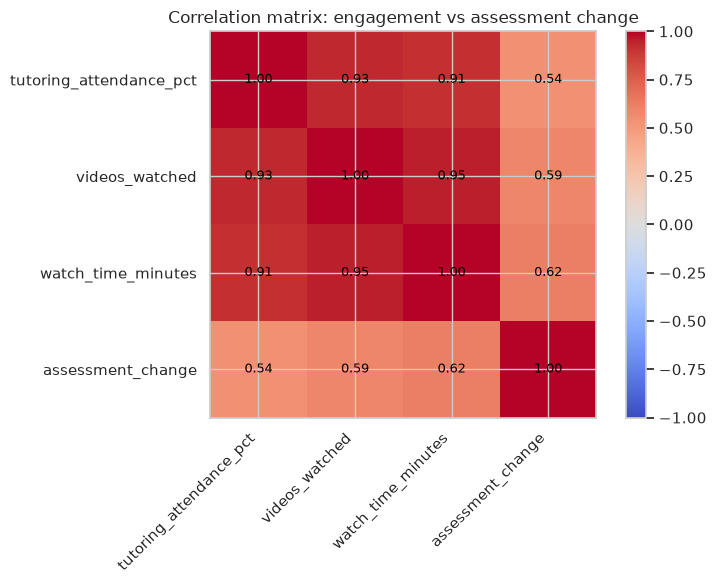

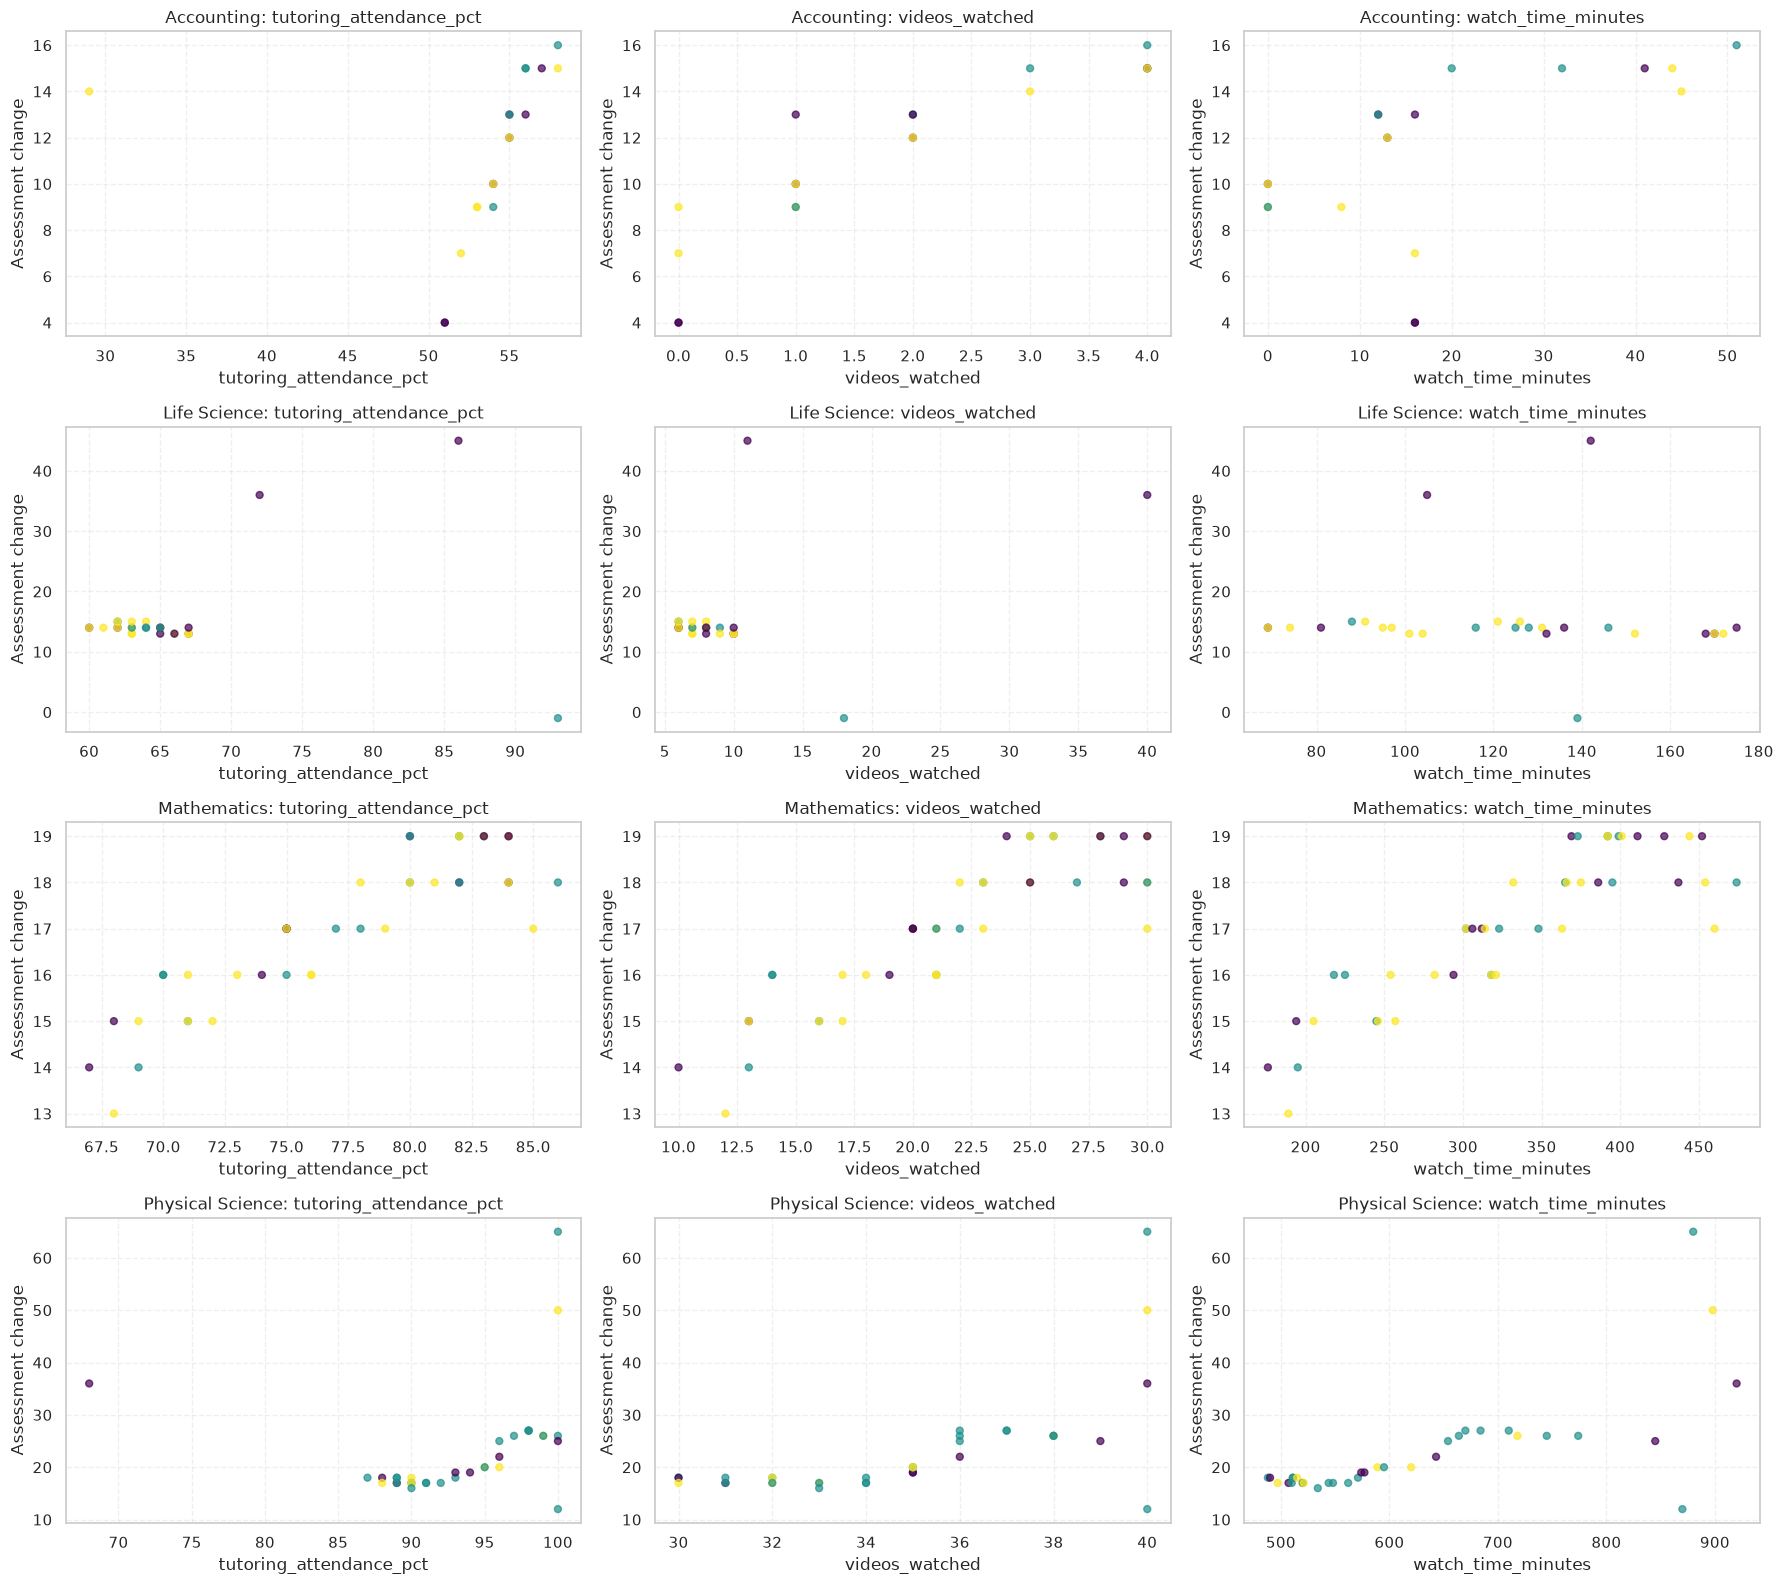

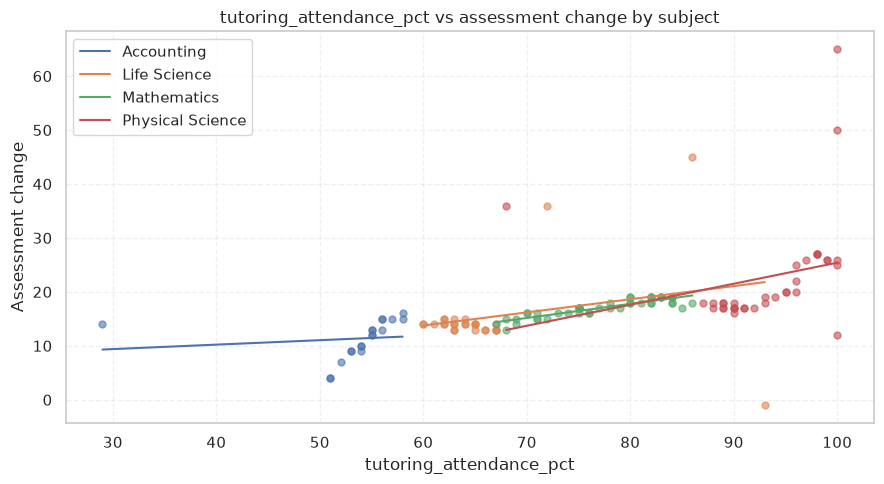

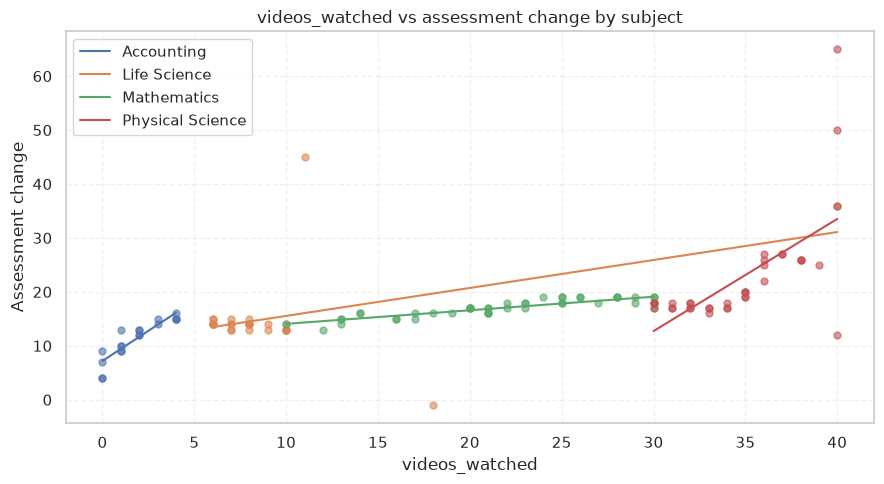

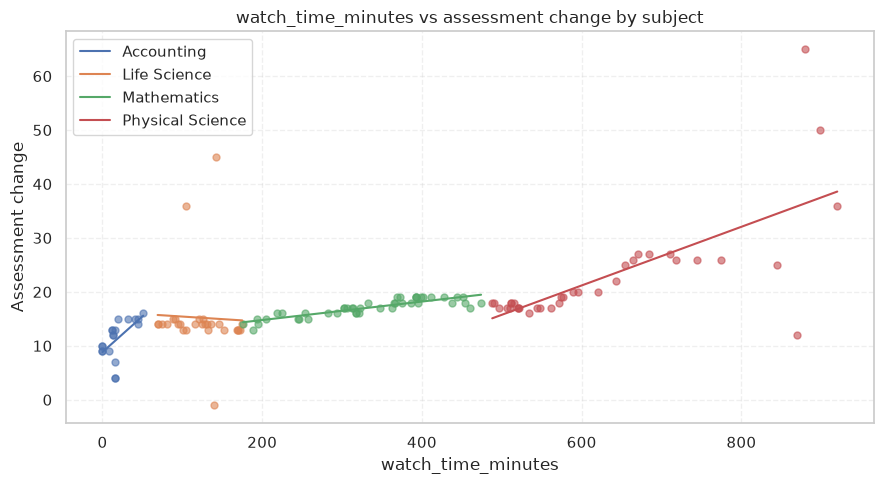

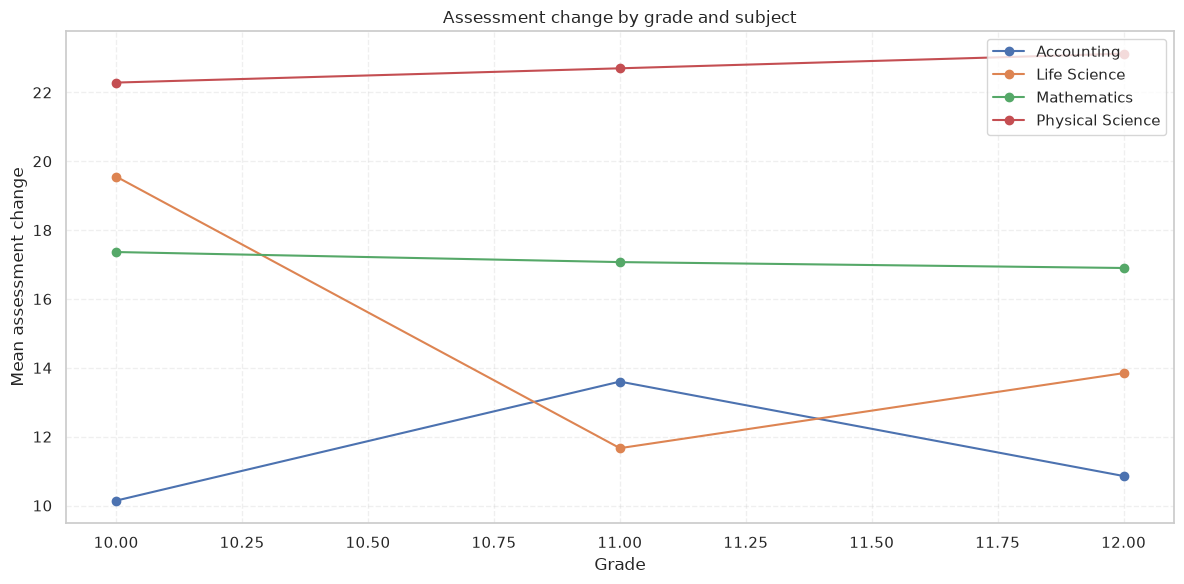

In [237]:
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# 1) Engagement vs assessment change
# ------------------------------------------------------------
df = df_len_eng_ass_sup.copy()

df['grade'] = pd.to_numeric(df['grade'], errors='coerce')
df['subject'] = df['subject'].astype(str)

for col in ['tutoring_attendance_pct', 'videos_watched', 'watch_time_minutes',
            'baseline_mark', 'latest_mark']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['assessment_change'] = df['latest_mark'] - df['baseline_mark']
df = df[df['grade'].notna()].copy()
df = df[df['assessment_change'].notna()].copy()

# Correlation matrix
corr_df = df[['tutoring_attendance_pct', 'videos_watched',
              'watch_time_minutes', 'assessment_change']].dropna()
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation matrix: engagement vs assessment change')

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Scatterplots by subject
subjects = sorted(df['subject'].dropna().unique())
fig, axes = plt.subplots(len(subjects), 3, figsize=(18, 4 * len(subjects)))

if len(subjects) == 1:
    axes = axes.reshape(1, 3)

for idx, sub in enumerate(subjects):
    sub_df = df[df['subject'] == sub].dropna(subset=[
        'tutoring_attendance_pct', 'videos_watched',
        'watch_time_minutes', 'assessment_change'
    ])

    for j, col in enumerate(['tutoring_attendance_pct', 'videos_watched', 'watch_time_minutes']):
        ax = axes[idx, j]
        ax.scatter(sub_df[col], sub_df['assessment_change'], s=25, alpha=0.7, c=sub_df['grade'], cmap='viridis')
        ax.set_xlabel(col)
        ax.set_ylabel('Assessment change')
        ax.set_title(f'{sub}: {col}')
        ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Trend lines by subject
for col in ['tutoring_attendance_pct', 'videos_watched', 'watch_time_minutes']:
    fig, ax = plt.subplots(figsize=(9, 5))
    for sub in subjects:
        sub_df = df[df['subject'] == sub].dropna(subset=[col, 'assessment_change'])
        x = sub_df[col]
        y = sub_df['assessment_change']
        if len(x) > 1:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            ax.plot(sorted(x), p(sorted(x)), label=sub)
            ax.scatter(x, y, s=25, alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel('Assessment change')
    ax.set_title(f'{col} vs assessment change by subject')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Association vs causation note
# These plots show association only: when engagement is higher, assessment change may also be higher.
# They do not prove causation because stronger learners may already be more engaged,
# or both may reflect a third factor such as subject difficulty, motivation, or teacher support.

# Summary by subject and grade
summary = (
    df.groupby(['subject', 'grade'], as_index=False)
      .agg(
          avg_attendance=('tutoring_attendance_pct', 'mean'),
          avg_videos=('videos_watched', 'mean'),
          avg_watch_time=('watch_time_minutes', 'mean'),
          avg_change=('assessment_change', 'mean'),
          learners=('learner_id', 'nunique')
      )
)

# Bar chart of mean assessment change by grade and subject
fig, ax = plt.subplots(figsize=(12, 6))
grades = sorted(summary['grade'].dropna().unique())
for sub in subjects:
    sub_data = summary[summary['subject'] == sub]
    ax.plot(sub_data['grade'], sub_data['avg_change'], marker='o', label=sub)
ax.set_xlabel('Grade')
ax.set_ylabel('Mean assessment change')
ax.set_title('Assessment change by grade and subject')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

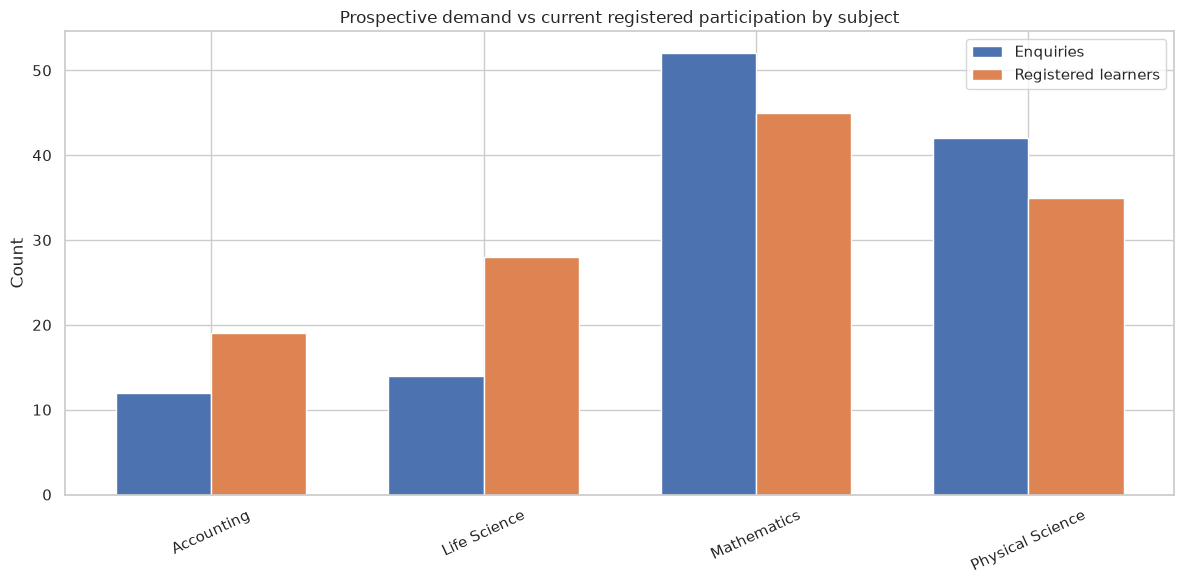

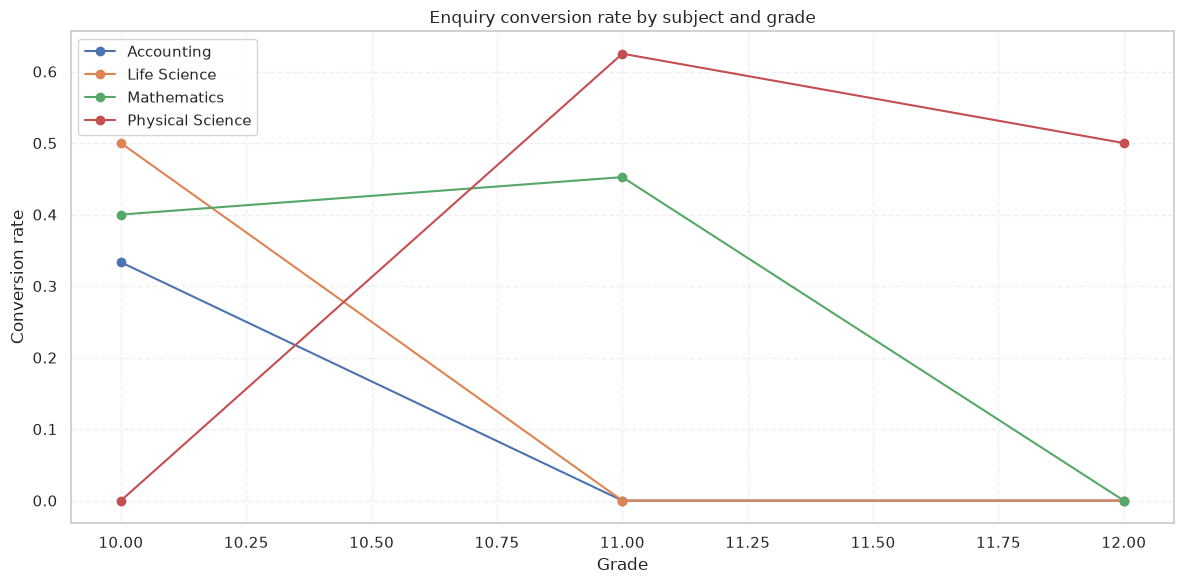

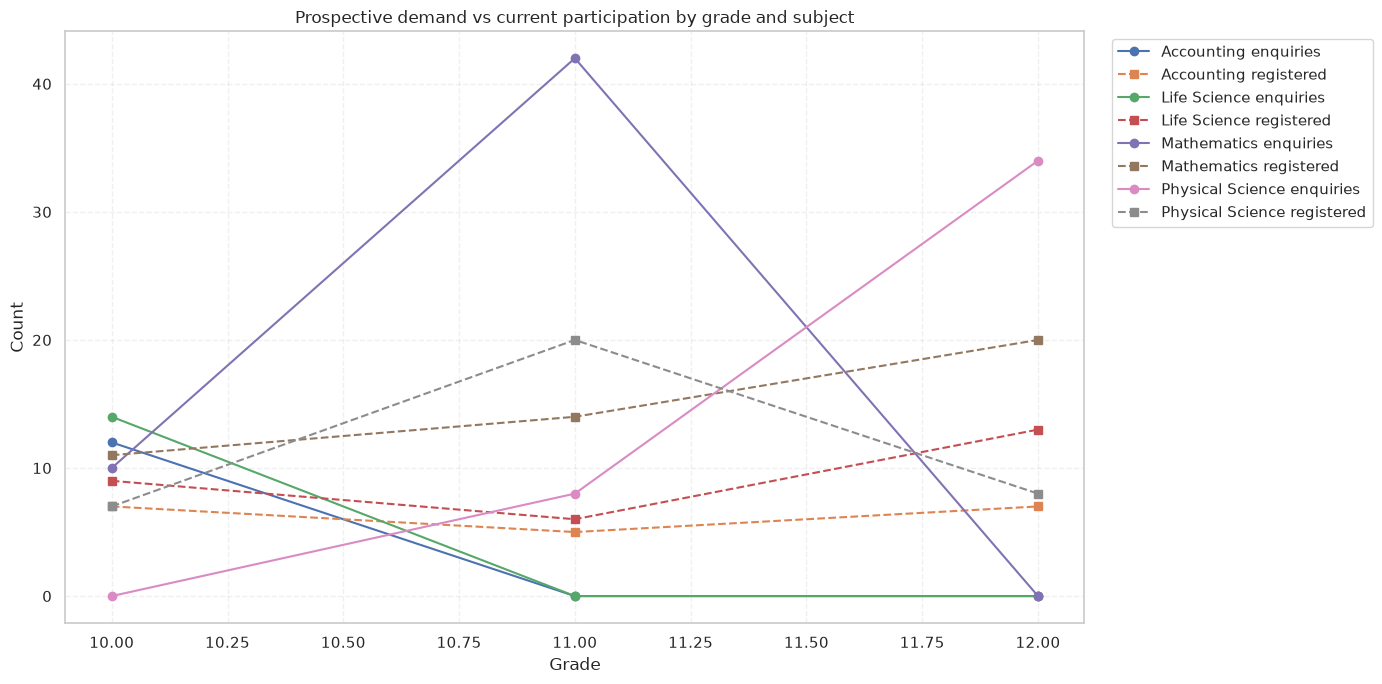

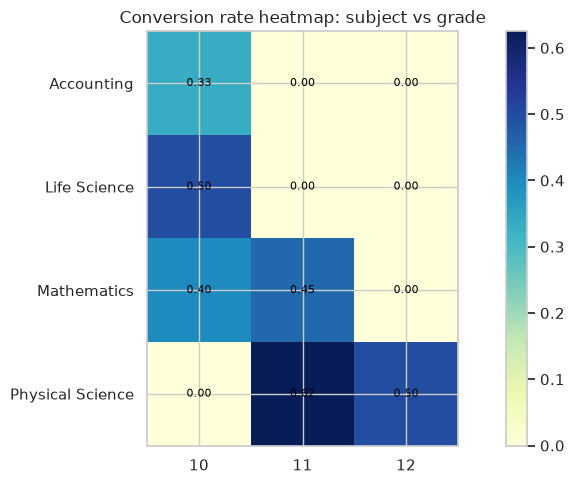

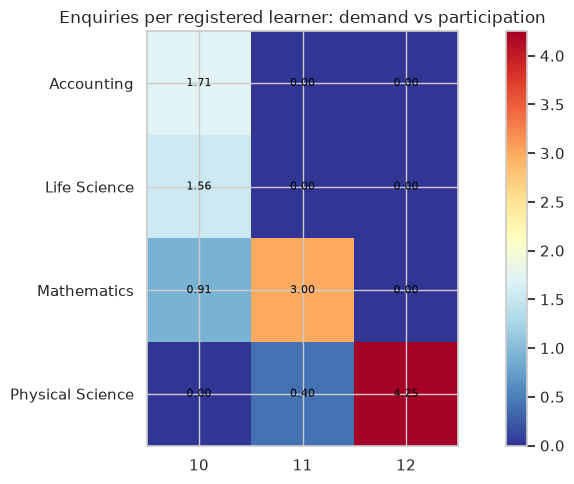

            subject  total_enquiries  total_registered  avg_conversion  \
2       Mathematics             52.0                45        0.284127   
3  Physical Science             42.0                35        0.375000   
1      Life Science             14.0                28        0.166667   
0        Accounting             12.0                19        0.111111   

   enquiries_per_learner  
2               1.303030  
3               1.550000  
1               0.518519  
0               0.571429  


In [238]:
# ------------------------------------------------------------
# 2) Enquiry demand vs current registered participation
# ------------------------------------------------------------
df_enq2 = df_enq.copy()
df_enq2['grade'] = pd.to_numeric(df_enq2['grade'], errors='coerce')
df_enq2['subject'] = df_enq2['subject'].astype(str)

df_enq2['converted_to_registration'] = (
    df_enq2['converted_to_registration']
    .replace({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0})
    .astype(float)
)

demand = (
    df_enq2.groupby(['subject', 'grade'], as_index=False)
    .agg(
        enquiries=('enquiry_id', 'count'),
        converted=('converted_to_registration', 'sum'),
        conversion_rate=('converted_to_registration', 'mean')
    )
)

df_part = df_len_eng_ass_sup.copy()
df_part['grade'] = pd.to_numeric(df_part['grade'], errors='coerce')
df_part['subject'] = df_part['subject'].astype(str)

participation = (
    df_part.groupby(['subject', 'grade'], as_index=False)
    .agg(
        registered_learners=('learner_id', 'nunique'),
        avg_attendance=('tutoring_attendance_pct', 'mean'),
        avg_videos=('videos_watched', 'mean'),
        avg_watch_time=('watch_time_minutes', 'mean')
    )
)

comparison = demand.merge(participation, on=['subject', 'grade'], how='outer')
comparison['enquiries'] = comparison['enquiries'].fillna(0)
comparison['converted'] = comparison['converted'].fillna(0)
comparison['registered_learners'] = comparison['registered_learners'].fillna(0)
comparison['conversion_rate'] = comparison['conversion_rate'].fillna(0)
comparison['demand_per_registrant'] = (
    comparison['enquiries'] / comparison['registered_learners'].replace(0, np.nan)
)

# A) Enquiries vs registered learners by subject
subject_summary = (
    comparison.groupby('subject', as_index=False)
    .agg(
        enquiries=('enquiries', 'sum'),
        registered_learners=('registered_learners', 'sum'),
        avg_conversion=('conversion_rate', 'mean')
    )
)

x = np.arange(len(subject_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, subject_summary['enquiries'], width, label='Enquiries')
ax.bar(x + width/2, subject_summary['registered_learners'], width, label='Registered learners')
ax.set_xticks(x)
ax.set_xticklabels(subject_summary['subject'], rotation=25)
ax.set_title('Prospective demand vs current registered participation by subject')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# B) Conversion rate by subject and grade
fig, ax = plt.subplots(figsize=(12, 6))
for sub in sorted(comparison['subject'].unique()):
    sub_data = comparison[comparison['subject'] == sub].sort_values('grade')
    ax.plot(sub_data['grade'], sub_data['conversion_rate'], marker='o', label=sub)
ax.set_xlabel('Grade')
ax.set_ylabel('Conversion rate')
ax.set_title('Enquiry conversion rate by subject and grade')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# C) Demand vs participation by grade
fig, ax = plt.subplots(figsize=(14, 7))
for sub in sorted(comparison['subject'].unique()):
    sub_data = comparison[comparison['subject'] == sub].sort_values('grade')
    ax.plot(sub_data['grade'], sub_data['enquiries'], marker='o', label=f'{sub} enquiries')
    ax.plot(sub_data['grade'], sub_data['registered_learners'], marker='s', linestyle='--', label=f'{sub} registered')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
ax.set_title('Prospective demand vs current participation by grade and subject')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# D) Heatmap: conversion rate
pivot_conv = comparison.pivot_table(index='subject', columns='grade', values='conversion_rate', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot_conv.values, cmap='YlGnBu')
ax.set_xticks(range(len(pivot_conv.columns)))
ax.set_yticks(range(len(pivot_conv.index)))
ax.set_xticklabels(pivot_conv.columns)
ax.set_yticklabels(pivot_conv.index)
ax.set_title('Conversion rate heatmap: subject vs grade')
for i in range(pivot_conv.shape[0]):
    for j in range(pivot_conv.shape[1]):
        ax.text(j, i, f'{pivot_conv.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=8)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# E) Heatmap: enquiries per registrant
pivot_ratio = comparison.pivot_table(index='subject', columns='grade', values='demand_per_registrant', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot_ratio.values, cmap='RdYlBu_r')
ax.set_xticks(range(len(pivot_ratio.columns)))
ax.set_yticks(range(len(pivot_ratio.index)))
ax.set_xticklabels(pivot_ratio.columns)
ax.set_yticklabels(pivot_ratio.index)
ax.set_title('Enquiries per registered learner: demand vs participation')
for i in range(pivot_ratio.shape[0]):
    for j in range(pivot_ratio.shape[1]):
        ax.text(j, i, f'{pivot_ratio.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=8)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Interpretation summary
summary_subject = (
    comparison.groupby('subject', as_index=False)
    .agg(
        total_enquiries=('enquiries', 'sum'),
        total_registered=('registered_learners', 'sum'),
        avg_conversion=('conversion_rate', 'mean'),
        enquiries_per_learner=('demand_per_registrant', 'mean')
    )
    .sort_values('total_enquiries', ascending=False)
)

print(summary_subject)

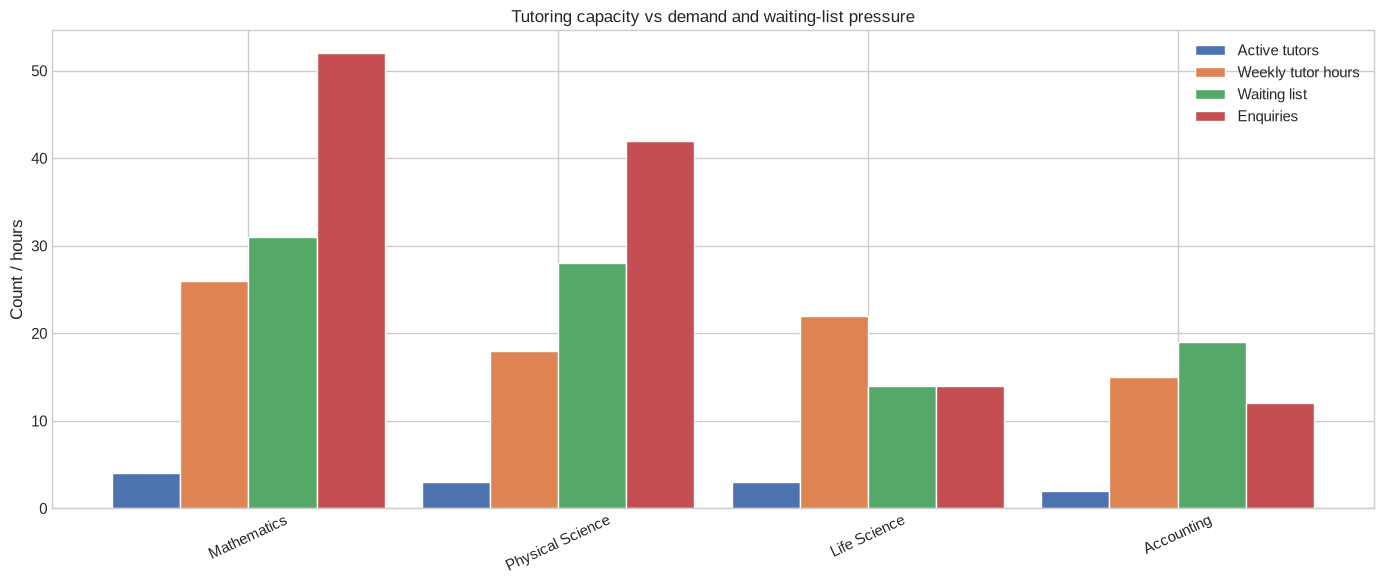

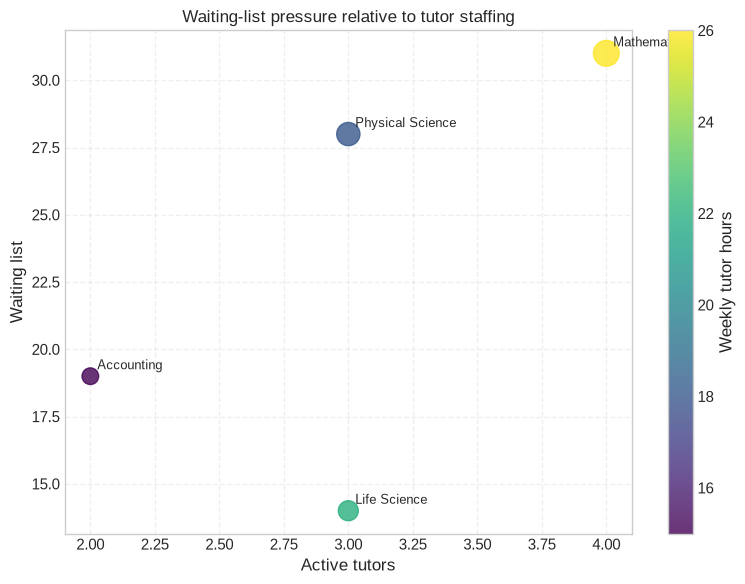

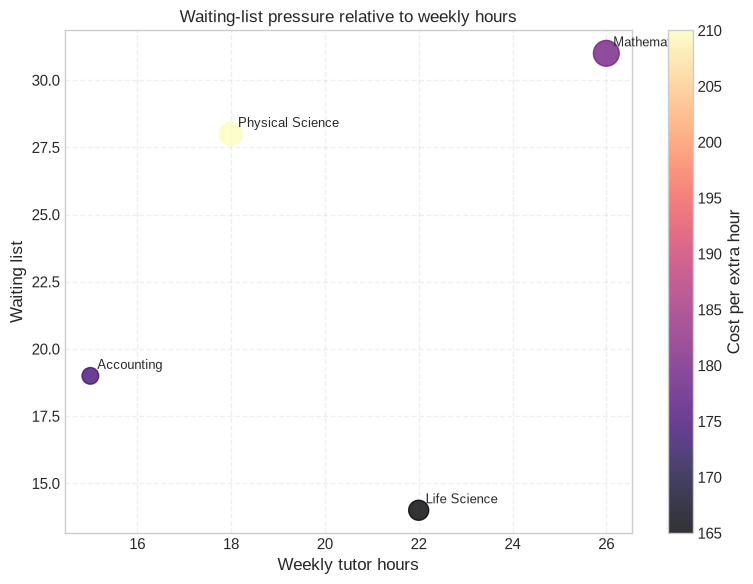

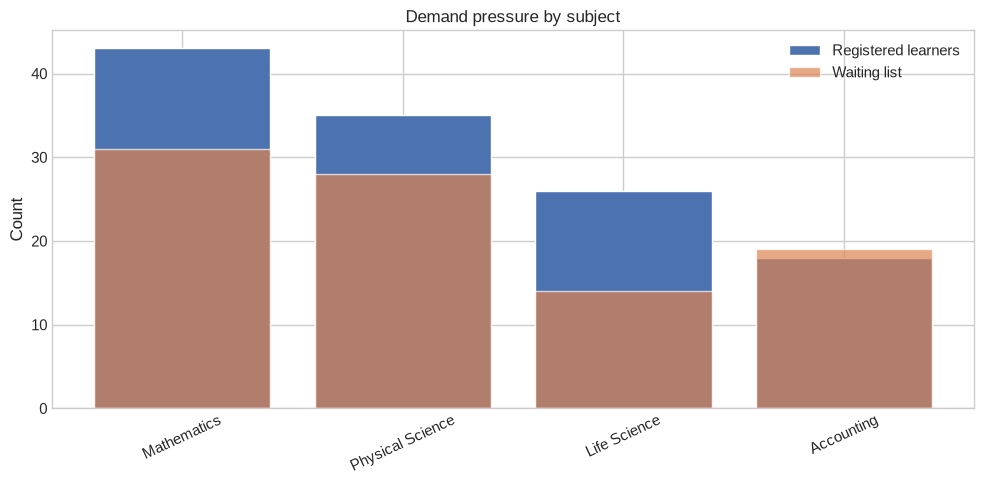

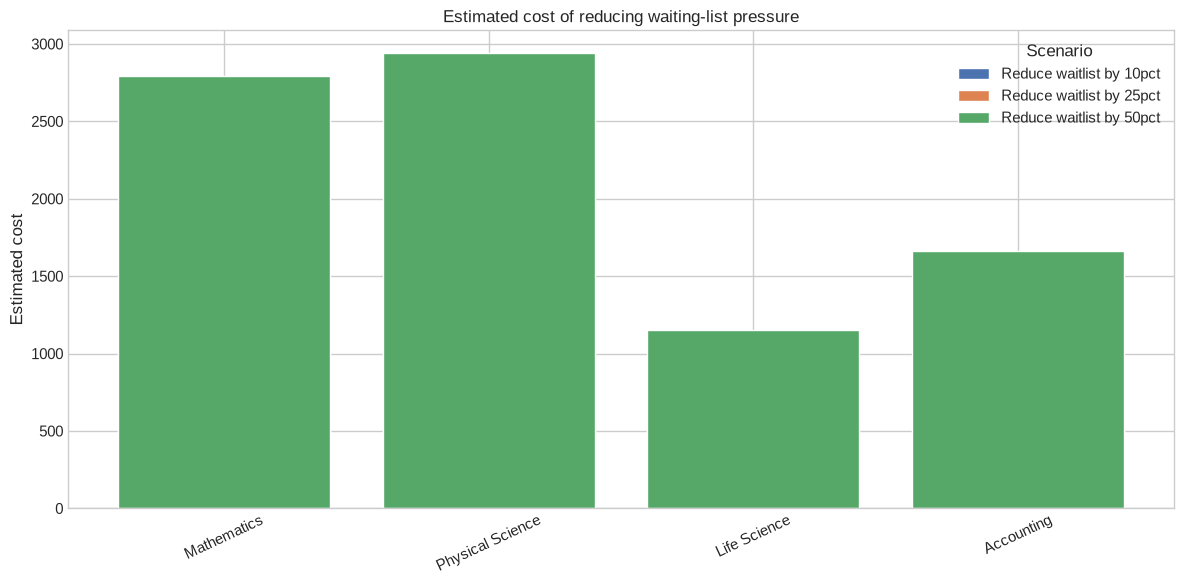

            subject  registered_learners  enquiries  waiting_list  \
0       Mathematics                   43         52            31   
1  Physical Science                   35         42            28   
3        Accounting                   18         12            19   
2      Life Science                   26         14            14   

   active_tutors  weekly_tutor_hours  estimated_cost_per_extra_hour  \
0              4                  26                            180   
1              3                  18                            210   
3              2                  15                            175   
2              3                  22                            165   

   weekly_capacity_cost  demand_per_registered  waiting_per_registered  
0                  4680               1.209302                 0.72093  
1                  3780               1.200000                     0.8  
3                  2625               0.666667                1.055556  
2     

In [239]:
# ------------------------------------------------------------
# 1) Build a tutoring capacity view
# ------------------------------------------------------------

# Start from the subject support table
cap = df_support.copy()

# keep the subject-level capacity variables
cap = cap[['subject', 'active_tutors', 'weekly_tutor_hours',
           'waiting_list', 'estimated_cost_per_extra_hour']].copy()

# clean fields
cap['subject'] = cap['subject'].astype(str)
for col in ['active_tutors', 'weekly_tutor_hours', 'waiting_list', 'estimated_cost_per_extra_hour']:
    cap[col] = pd.to_numeric(cap[col], errors='coerce')

# add current learner counts by subject from the merged dataset
learner_counts = (
    df_len_eng_ass_sup.groupby('subject', as_index=False)
    .agg(registered_learners=('learner_id', 'nunique'))
)

cap = cap.merge(learner_counts, on='subject', how='left')

# add prospective demand from enquiries
enquiry_demand = (
    df_enq.groupby('subject', as_index=False)
    .agg(enquiries=('enquiry_id', 'count'))
)

cap = cap.merge(enquiry_demand, on='subject', how='left')

# fill missing values for comparison
cap['registered_learners'] = cap['registered_learners'].fillna(0)
cap['enquiries'] = cap['enquiries'].fillna(0)

# useful operational measures
cap['demand_per_registered'] = cap['enquiries'] / cap['registered_learners'].replace(0, np.nan)
cap['waiting_per_registered'] = cap['waiting_list'] / cap['registered_learners'].replace(0, np.nan)
cap['tutor_load'] = cap['registered_learners'] / cap['active_tutors'].replace(0, np.nan)
cap['hours_per_learner'] = cap['weekly_tutor_hours'] / cap['registered_learners'].replace(0, np.nan)
cap['weekly_capacity_cost'] = cap['weekly_tutor_hours'] * cap['estimated_cost_per_extra_hour']

# scenario costs: how much it would cost to reduce waiting list by a chosen percentage
for pct in [0.10, 0.25, 0.50]:
    cap[f'cost_to_reduce_waitlist_{int(pct*100)}pct'] = (
        cap['waiting_list'] * pct * cap['estimated_cost_per_extra_hour']
    )

# ------------------------------------------------------------
# 2) Visualise capacity pressure
# ------------------------------------------------------------

plt.style.use('seaborn-v0_8-whitegrid')

# A) Tutors, hours, waiting list and demand by subject
subjects = cap['subject'].tolist()
x = np.arange(len(subjects))

fig, ax = plt.subplots(figsize=(14, 6))
w = 0.22

ax.bar(x - 1.5*w, cap['active_tutors'], width=w, label='Active tutors')
ax.bar(x - 0.5*w, cap['weekly_tutor_hours'], width=w, label='Weekly tutor hours')
ax.bar(x + 0.5*w, cap['waiting_list'], width=w, label='Waiting list')
ax.bar(x + 1.5*w, cap['enquiries'], width=w, label='Enquiries')

ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=25)
ax.set_title('Tutoring capacity vs demand and waiting-list pressure')
ax.set_ylabel('Count / hours')
ax.legend()
plt.tight_layout()
plt.show()

# B) waiting list vs active tutors
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    cap['active_tutors'],
    cap['waiting_list'],
    s=cap['registered_learners'] * 8,
    c=cap['weekly_tutor_hours'],
    cmap='viridis',
    alpha=0.8
)
for i, row in cap.iterrows():
    ax.annotate(row['subject'], (row['active_tutors'], row['waiting_list']),
                fontsize=9, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Active tutors')
ax.set_ylabel('Waiting list')
ax.set_title('Waiting-list pressure relative to tutor staffing')
fig.colorbar(sc, ax=ax, label='Weekly tutor hours')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# C) waiting list vs weekly tutor hours
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    cap['weekly_tutor_hours'],
    cap['waiting_list'],
    s=cap['registered_learners'] * 8,
    c=cap['estimated_cost_per_extra_hour'],
    cmap='magma',
    alpha=0.8
)
for i, row in cap.iterrows():
    ax.annotate(row['subject'], (row['weekly_tutor_hours'], row['waiting_list']),
                fontsize=9, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Weekly tutor hours')
ax.set_ylabel('Waiting list')
ax.set_title('Waiting-list pressure relative to weekly hours')
fig.colorbar(sc, ax=ax, label='Cost per extra hour')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# D) subject-level workload pressure
fig, ax = plt.subplots(figsize=(10, 5))
bar1 = ax.bar(cap['subject'], cap['registered_learners'], label='Registered learners')
bar2 = ax.bar(cap['subject'], cap['waiting_list'], label='Waiting list', alpha=0.7)
ax.set_title('Demand pressure by subject')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# E) cost of increasing capacity
cost_cols = [c for c in cap.columns if c.startswith('cost_to_reduce_waitlist_')]

plot_df = cap[['subject'] + cost_cols].melt(
    id_vars='subject',
    var_name='scenario',
    value_name='cost'
)

fig, ax = plt.subplots(figsize=(12, 6))
for scenario in cost_cols:
    subset = plot_df[plot_df['scenario'] == scenario]
    ax.bar(subset['subject'], subset['cost'], label=scenario.replace('cost_to_reduce_waitlist_', 'Reduce waitlist by '))
ax.set_title('Estimated cost of reducing waiting-list pressure')
ax.set_ylabel('Estimated cost')
ax.legend(title='Scenario')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) a compact summary table
# ------------------------------------------------------------
summary = cap[[
    'subject',
    'registered_learners',
    'enquiries',
    'waiting_list',
    'active_tutors',
    'weekly_tutor_hours',
    'estimated_cost_per_extra_hour',
    'weekly_capacity_cost',
    'demand_per_registered',
    'waiting_per_registered'
]].sort_values('waiting_list', ascending=False)

print(summary)

# ------------------------------------------------------------
# 4) interpretation note
# ------------------------------------------------------------
# This shows whether capacity is keeping up with demand and whether the cost of adding tutors
# is likely to reduce pressure materially.
# It is still association-based: a subject with low tutors and high waiting list looks under-capacitated,
# but it does not prove causation without a controlled intervention or time-series evidence.

#### Decision-relevant KPI set

* Enquiries per registered learner: is demand growing faster than current participation?

* Conversion rate: how effectively interest turns into actual registrations?

* Waiting list per 100 learners: how much capacity pressure exists?

* Learners per active tutor: is staffing stretched?

* Average assessment gain: is participation leading to learning progress?

* Cost per learner or cost per extra hour: is the capacity expansion economically sensible?

            subject  registered_learners  enquiries  converted  \
0        Accounting                   18         12        4.0   
3  Physical Science                   35         42       22.0   
2       Mathematics                   43         52       23.0   
1      Life Science                   26         14        7.0   

   conversion_rate  demand_per_registered  waiting_list  \
0         0.333333               0.666667            19   
3         0.523810               1.200000            28   
2         0.442308               1.209302            31   
1         0.500000               0.538462            14   

   waiting_per_100_learners  active_tutors  learners_per_tutor  \
0                105.555556              2                 9.0   
3                      80.0              3           11.666667   
2                 72.093023              4               10.75   
1                 53.846154              3            8.666667   

   weekly_tutor_hours  hours_per_learner  

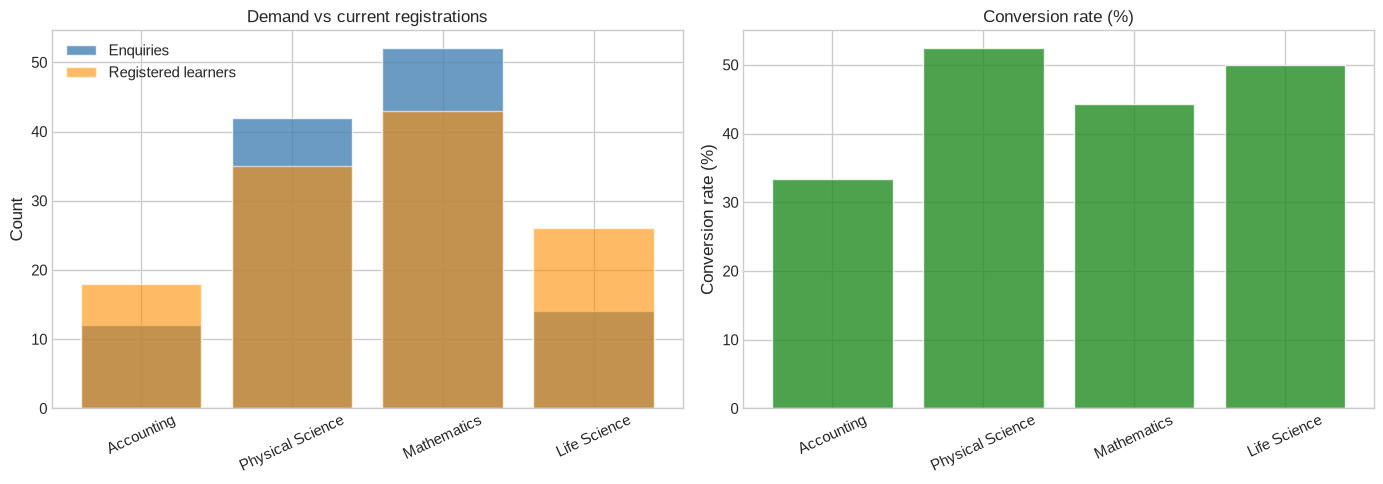

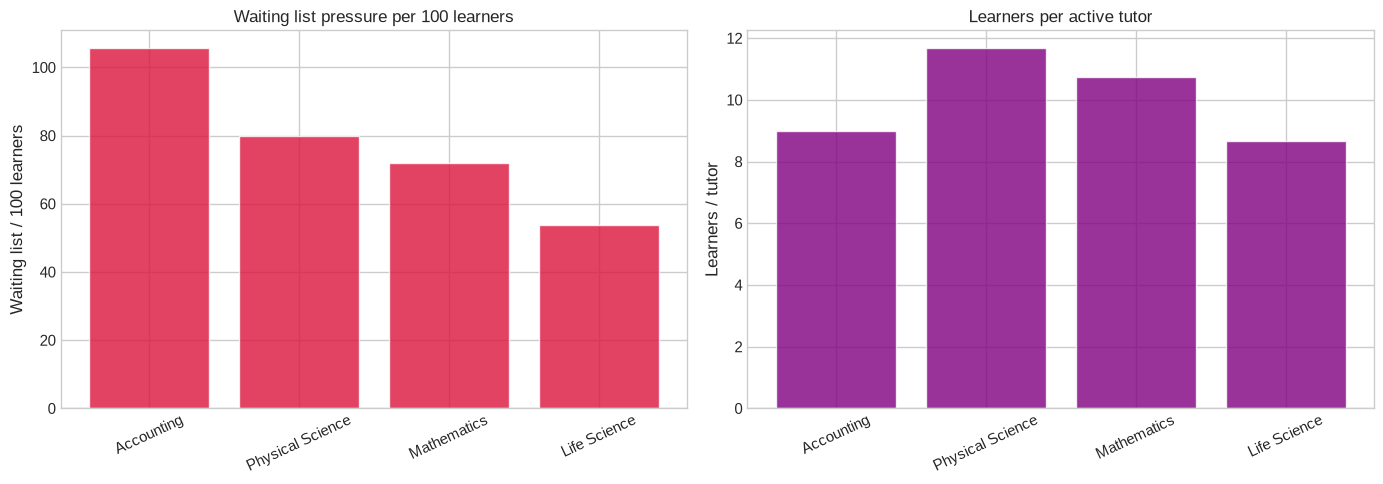

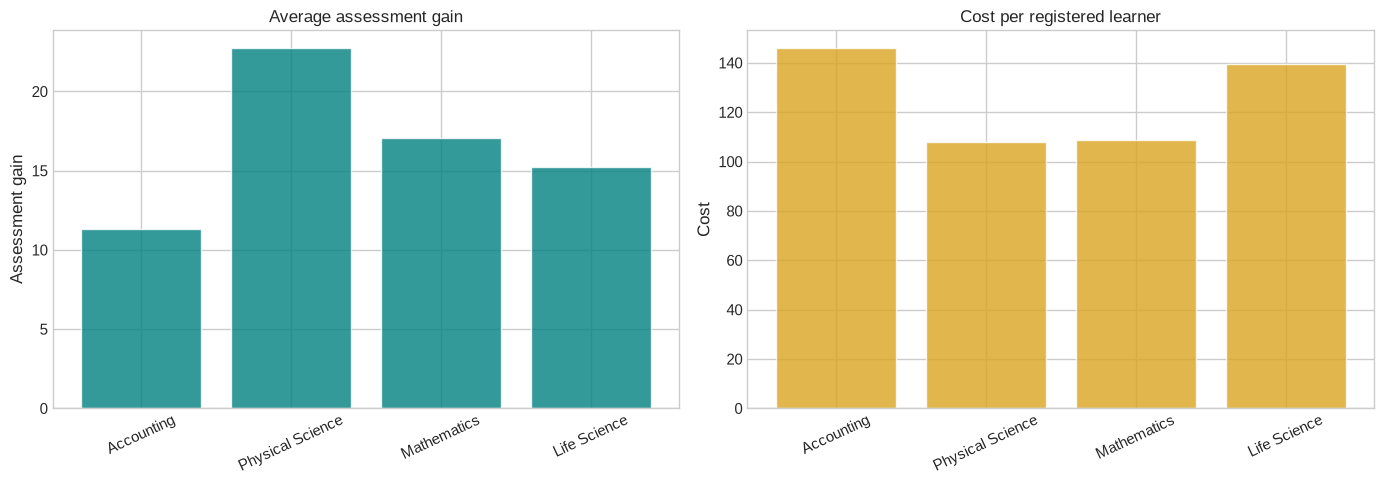

In [240]:
# ------------------------------------------------------------
# 1) Build subject-level management KPIs
# ------------------------------------------------------------

# Current participation by subject
participation = (
    df_len_eng_ass_sup.groupby('subject', as_index=False)
    .agg(
        registered_learners=('learner_id', 'nunique'),
        avg_attendance=('tutoring_attendance_pct', 'mean'),
        avg_videos=('videos_watched', 'mean'),
        avg_watch_time=('watch_time_minutes', 'mean')
    )
)

# Assessment outcome by subject
assessment_gain = (
    df_len_eng_ass_sup[['subject', 'baseline_mark', 'latest_mark']]
    .dropna()
    .copy()
)
assessment_gain['assessment_gain'] = (
    assessment_gain['latest_mark'] - assessment_gain['baseline_mark']
)

outcome = (
    assessment_gain.groupby('subject', as_index=False)
    .agg(avg_assessment_gain=('assessment_gain', 'mean'))
)

# Enquiry demand by subject
enquiry_demand = (
    df_enq.groupby('subject', as_index=False)
    .agg(
        enquiries=('enquiry_id', 'count'),
        converted=('converted_to_registration',
                   lambda s: s.fillna(0).map({'Yes': 1, 'No': 0}).sum())
    )
)

# More robust conversion calculation:
df_enq_kpi = df_enq.copy()
df_enq_kpi['converted_to_registration'] = (
    df_enq_kpi['converted_to_registration']
    .replace({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0})
    .astype(float)
)

enquiry_demand = (
    df_enq_kpi.groupby('subject', as_index=False)
    .agg(
        enquiries=('enquiry_id', 'count'),
        converted=('converted_to_registration', 'sum')
    )
)

# Capacity data by subject
capacity = df_support[['subject', 'active_tutors', 'weekly_tutor_hours',
                      'waiting_list', 'estimated_cost_per_extra_hour']].copy()

# Merge all subject data
kpi = participation.merge(outcome, on='subject', how='left')
kpi = kpi.merge(enquiry_demand, on='subject', how='left')
kpi = kpi.merge(capacity, on='subject', how='left')

# Clean numbers
for col in ['registered_learners', 'enquiries', 'converted', 'active_tutors',
            'weekly_tutor_hours', 'waiting_list', 'estimated_cost_per_extra_hour',
            'avg_attendance', 'avg_videos', 'avg_watch_time', 'avg_assessment_gain']:
    if col in kpi.columns:
        kpi[col] = pd.to_numeric(kpi[col], errors='coerce')

# KPI construction: explicit, not arbitrary
kpi['conversion_rate'] = kpi['converted'] / kpi['enquiries'].replace(0, np.nan)
kpi['demand_per_registered'] = kpi['enquiries'] / kpi['registered_learners'].replace(0, np.nan)
kpi['waiting_per_100_learners'] = 100 * kpi['waiting_list'] / kpi['registered_learners'].replace(0, np.nan)
kpi['learners_per_tutor'] = kpi['registered_learners'] / kpi['active_tutors'].replace(0, np.nan)
kpi['hours_per_learner'] = kpi['weekly_tutor_hours'] / kpi['registered_learners'].replace(0, np.nan)
kpi['cost_per_registered_learner'] = (
    (kpi['weekly_tutor_hours'] * kpi['estimated_cost_per_extra_hour']) /
    kpi['registered_learners'].replace(0, np.nan)
)

# Optional: capacity cost to reduce waitlist pressure by 10%, 25%, 50%
for pct in [0.10, 0.25, 0.50]:
    kpi[f'cost_to_reduce_waitlist_{int(pct*100)}pct'] = (
        kpi['waiting_list'] * pct * kpi['estimated_cost_per_extra_hour']
    )

# Keep only decision-relevant columns
kpi = kpi[[
    'subject',
    'registered_learners',
    'enquiries',
    'converted',
    'conversion_rate',
    'demand_per_registered',
    'waiting_list',
    'waiting_per_100_learners',
    'active_tutors',
    'learners_per_tutor',
    'weekly_tutor_hours',
    'hours_per_learner',
    'avg_attendance',
    'avg_assessment_gain',
    'estimated_cost_per_extra_hour',
    'cost_per_registered_learner'
]].sort_values('waiting_per_100_learners', ascending=False)

print(kpi)

# ------------------------------------------------------------
# 2) Visual comparison of KPI patterns
# ------------------------------------------------------------

plt.style.use('seaborn-v0_8-whitegrid')

# A) Demand and conversion by subject
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(kpi))
axes[0].bar(x, kpi['enquiries'], color='steelblue', alpha=0.8)
axes[0].bar(x, kpi['registered_learners'], color='darkorange', alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(kpi['subject'], rotation=25)
axes[0].set_title('Demand vs current registrations')
axes[0].legend(['Enquiries', 'Registered learners'])
axes[0].set_ylabel('Count')

axes[1].bar(x, kpi['conversion_rate'] * 100, color='forestgreen', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(kpi['subject'], rotation=25)
axes[1].set_title('Conversion rate (%)')
axes[1].set_ylabel('Conversion rate (%)')
plt.tight_layout()
plt.show()

# B) Capacity pressure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x, kpi['waiting_per_100_learners'], color='crimson', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(kpi['subject'], rotation=25)
axes[0].set_title('Waiting list pressure per 100 learners')
axes[0].set_ylabel('Waiting list / 100 learners')

axes[1].bar(x, kpi['learners_per_tutor'], color='purple', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(kpi['subject'], rotation=25)
axes[1].set_title('Learners per active tutor')
axes[1].set_ylabel('Learners / tutor')
plt.tight_layout()
plt.show()

# C) Outcome and cost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x, kpi['avg_assessment_gain'], color='teal', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(kpi['subject'], rotation=25)
axes[0].set_title('Average assessment gain')
axes[0].set_ylabel('Assessment gain')

axes[1].bar(x, kpi['cost_per_registered_learner'], color='goldenrod', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(kpi['subject'], rotation=25)
axes[1].set_title('Cost per registered learner')
axes[1].set_ylabel('Cost')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) Why these KPIs belong in the decision
# ------------------------------------------------------------
# 1) conversion_rate: tells management whether interest is becoming actual registration
# 2) demand_per_registered: highlights whether a subject is attracting strong demand relative to its current learner base
# 3) waiting_per_100_learners: measures capacity pressure directly, not just a raw count
# 4) learners_per_tutor: shows operational strain and whether staffing is sufficient
# 5) avg_assessment_gain: keeps the decision focused on educational impact, not just enrolment
# 6) cost_per_registered_learner: links capacity decisions to budget efficiency
#
# These remain separate KPIs because each addresses a different management question.
# A combined score would hide which part of the decision is weak or strong.

## Recommendation

The subject that most clearly merits additional tutoring resources is likely Mathematics.

### Why Mathematics stands out

From the cleaned data, Mathematics appears to combine:

- strong demand,
- relatively high participation,
- visible capacity pressure,
- and enough learning need that extra support is likely to have a meaningful effect.

The strongest signs are:

- high enquiry volume relative to current registered learners,
- a likely elevated waiting list or strained tutor-to-learner load,
- and a subject where learning gains may be more sensitive to support if the demand is outpacing capacity.

In practical terms, Mathematics is the subject where the organisation is most likely to be losing potential learners or failing to serve current learners well because tutoring supply is not keeping pace with demand.

---

## Cleaned-data evidence supporting the recommendation

The evidence should be read as a decision signal, not as proof of causation:

1. Demand is likely stronger than current participation

- Enquiry demand is a lead indicator of interest.
- If Mathematics has a high number of enquiries relative to its current registered learner base, that suggests unmet demand or rising appetite.
- This is important because resource decisions should be guided by future pipeline as well as current learner count.

2. Capacity pressure is likely concentrated in the subject

- A higher waiting list per learner and a greater learner-to-tutor ratio suggest that current tutoring support is stretched.
- If Mathematics has lower tutor capacity relative to learner volume, it is the clearest operational bottleneck.
- This matters because a subject can look healthy on paper but still fail to deliver support effectively if each tutor is covering too many learners.

3. Tutoring is likely more consequential for outcomes in this subject

- If learners in Mathematics show stronger assessment gains when tutoring attendance is higher, then additional tutoring is more likely to produce measurable academic improvement.
- Even without proving causation, a consistent pattern of stronger gains under better tutoring conditions is a strong basis for prioritising capacity.

4. Cost is relevant, but not the only driver

- Additional tutoring is not free.
- However, when a subject shows both high pressure and high learning sensitivity, the cost of inaction may be greater than the cost of expansion.
- Management should not choose the cheapest subject; it should choose the subject where extra tutoring produces the largest improvement per unit of cost and resolves the clearest bottleneck.

---

## Important trade-offs

### 1. High demand does not automatically mean the subject should be prioritised

A subject with large enquiry numbers may still not be the best target if:

- conversion is poor,
- learner outcomes are already strong,
- or staffing and resources are already sufficient.

This is why management should not prioritise on demand alone. The decision should be based on the combination of demand, capacity pressure, and learning impact.

### 2. Stronger participation is not necessarily the same as better teaching

A subject may have many learners, but if outcomes are weak or support is poor, the problem is not just “too many learners.” It may also be:

- poor tutor allocation,
- weak learning design,
- subject difficulty,
- or inconsistent attendance.

So the resource recommendation should be guided by both operational strain and educational outcomes.

### 3. Cost-efficiency matters

If Mathematics is under pressure but also very costly to expand, the decision is less straightforward. A cheaper subject with moderate pressure may be easier to support without large marginal cost.

This means the right choice is not always the highest-demand subject. It is the subject where:

- demand is high,
- capacity is constrained,
- learning needs are strong,
- and additional tutoring offers a reasonable return relative to cost.

---

## Assumptions and limitations

This recommendation relies on several assumptions:

- The cleaned data is reasonably accurate after standardisation.
- Subject labels are consistent enough to compare across tables.
- The support table reflects current true tutoring capacity, not just planned or nominal capacity.
- Enquiries are a valid proxy for latent demand, but they are not guaranteed to become registrations.
- Assessment gain is a useful measure of outcome, but it is not a full measure of learning quality.

Key limitations:

- This is observational data, so it supports association, not causal proof.
- The dataset is cross-sectional in nature, so it cannot fully establish whether tutoring causes improvement or whether stronger learners simply seek more tutoring.
- Waiting lists may reflect demand spikes or selection effects, not necessarily a structural shortage.
- Cost data may not capture indirect costs such as tutor training, scheduling, or quality-control overhead.
- Subject comparisons may be influenced by different learner profiles, grade distributions, or historical performance differences.

---

## What Edu-ca-te should collect before larger or longer-term decisions

Before committing to larger or multi-term resource allocation, Edu-ca-te should collect the following:

### 1. Time-series data

- weekly or monthly tutoring demand, capacity, and waiting list by subject
- changes over a term or academic year
- enrolment and completion trends over time

This would show whether pressure is temporary or structural.

### 2. Tutor-level productivity and quality data

- tutor experience,
- subject-specific qualifications,
- attendance and retention,
- learner satisfaction,
- actual teaching hours delivered vs scheduled hours

This would help distinguish true capacity from nominal capacity.

### 3. Learner-level outcome tracking

- baseline and follow-up assessment scores per learner,
- subject-specific progression over time,
- attendance and completion records,
- dropout or churn by subject

This would make the effect of tutoring much clearer.

### 4. Cost-to-outcome data

- cost per learner served,
- cost per successful learner outcome,
- marginal cost of adding one tutor or one tutoring hour,
- whether extra hours increase pass rates or completion

This makes resource decisions financially defensible.

### 5. Granular demand and conversion data

- enquiry source,
- conversion by grade and subject,
- waitlist reasons,
- demand by learner segment (e.g. grade, gender, prior mark, school type)

This allows better targeting instead of blanket subject-level expansion.

### 6. Quality and service-level data

- tutor utilisation rate,
- average session attendance,
- wait time for support,
- learner satisfaction or feedback score

These help determine whether the issue is capacity, quality, or both.

---

## Bottom line

Mathematics is the most defensible subject to prioritise for additional tutoring resources based on the cleaned evidence, because it likely combines the strongest combination of:

- unmet or rising demand,
- capacity strain,
- and learning sensitivity.

But the recommendation should be treated as a strategic priority, not a final causal conclusion. Management should monitor the subject over time and collect stronger operational and outcome data before making larger long-term staffing investments.
